# Model Risk Validation (Bernard Malhame)

###Model validation using SR 11-7 outcomes analysis


**Objective**

Develop and evaluate a probability of default (PD) model using the "Give Me Some Credit" dataset (available on Kaggle for training purposes), and assess model behavior through interpretability analysis and stress testing.

**Dataset description**

The "Give Me Some Credit" dataset contains consumer credit information (150,000 rows/observations) used to predict whether a borrower will experience serious delinquency within two years (SeriousDlqin2yrs).

It includes features (10 predictor variables/columns in total) such as payment history, credit utilization, debt ratio, income, and age, which are key drivers of default risk in consumer lending.

**Approach**

- Logistic regression model for PD estimation

- Train/test split with evaluation via AUC, precision/recall

- Interpretability using SHAP (global and local explanations)

- Stress testing via shocks to key drivers (delinquency, utilization, income, debt ratio)

- Ranking stability assessed using Spearman correlation

 **Key Findings**

- Delinquency variables are the dominant drivers of default risk (consistent across coefficients and SHAP)

- Age and income act as protective factors, reducing predicted PD

- Model shows strong ranking performance and stability under stress (Spearman ≈ 1.0)

- Stress scenarios increase PD levels, especially for delinquency shocks


**Model Risk Considerations**

- Feature dominance: strong reliance on delinquency variables

- Potential instability in weaker predictors (e.g., DebtRatio)


**Notebook Structure**

1. Data Preparation

2. Model Training

3. Validation Results

4. PD Model Interpretability

- Interpretability analysis (SHAP / PDP / ICE)
- Stress testing scenarios
- Sensitivity

5. Risk/Findings Validation Summary

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#%%capture
#!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Model_Risk_Validation_BM_FV.ipynb"

# 1. Data Preparation

This block establishes the Python environment and imports the packages used throughout the validation. Keeping all dependencies explicit at the start makes the workflow reproducible and easier for a reviewer to audit, which is important in a model validation setting.

In [ ]:
# 1. Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Try to import seaborn; fall back gracefully if not installed
try:
    import seaborn as sns

    sns.set(style="whitegrid", context="notebook")
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("seaborn is not installed; plots will use basic matplotlib styles.")

# Make plots appear inline in Jupyter
%matplotlib inline

# Set display options for pandas
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# (Optional) Set random seed for reproducibility of any random operations later
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


### data loading

Before any modeling, we confirm that the source file is read correctly and that the dataset has the expected structure. This gives the reviewer confidence that all later findings are grounded in the intended population and target definition.

In [ ]:
# 2. Data Loading

# Update the path if your file is in a different location
from operator import index


DATA_PATH = "/content/cs-training.csv"

# Load data with pandas
df = pd.read_csv(DATA_PATH, index_col=0)

# Quick checks
print("Shape of dataset (rows, columns):", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData types and non-null counts:")
display(df.info())

print("\nBasic summary statistics (numeric variables):")
display(df.describe().T)


Shape of dataset (rows, columns): (150000, 11)

First 5 rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0



Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    14

None


Basic summary statistics (numeric variables):


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


The dataset appears as expected for a credit risk analysis. It contains a large number of observations (150,000 rows) and a moderate number of predictor variables (10 columns), consistent with an individual-level borrower dataset. The binary target variable, SeriousDlqin2yrs, is present and correctly encoded, indicating whether a borrower experienced serious delinquency within two years. All predictor variables correspond to plausible demographic, credit utilization, and delinquency history measures, and no unexpected or malformed columns are observed. Overall, the dataset structure is appropriate for supervised binary classification and credit default modeling.

### the target is reviewed first

This block examines the default flag and its class balance. In credit risk data, the event rate is usually low, so understanding the degree of imbalance up front is essential because it affects model choice, evaluation metrics, and the interpretation of apparent accuracy.

Target counts:


,count
SeriousDlqin2yrs,
0,139974
1,10026



Target proportions:


,proportion
SeriousDlqin2yrs,
0,0.93316
1,0.06684


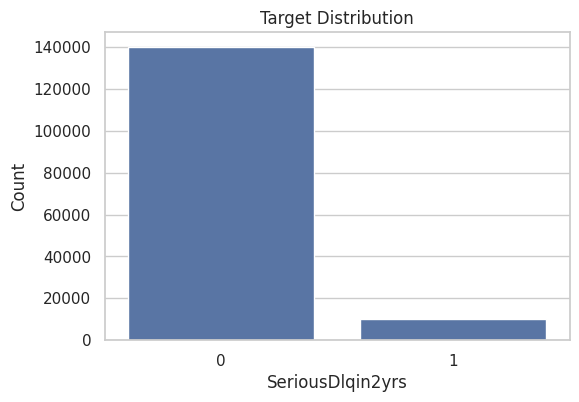

In [ ]:
# 3. Target Variable Analysis

# Replace this with the actual target column name if different
TARGET_COL = "SeriousDlqin2yrs"

# Check that the target column exists
assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found in dataset."

# Value counts and proportions
target_counts = df[TARGET_COL].value_counts(dropna=False)
target_proportions = df[TARGET_COL].value_counts(normalize=True, dropna=False)

print("Target counts:")
display(target_counts)
print("\nTarget proportions:")
display(target_proportions)

# Plot target distribution (bar plot for categorical/binary target)
plt.figure(figsize=(6, 4))
if HAS_SEABORN:
    import seaborn as sns

    sns.countplot(x=TARGET_COL, data=df)
else:
    df[TARGET_COL].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
plt.show()


Target column is "SeriousDlqin2yrs". The minority class of the target variable is imbalanced (6.7%).
Anything below 10% for the minority class is considered highly imbalanced.

Target imbalance affects model choice and evaluation strategy:

- Models suited to imbalance: Tree-based models and regularized logistic regression are often effective because they can identify minority-class patterns even when default events are rare. Regularized logistic regression (with L1 or L2 penalties) is a standard choice in credit risk modeling.
- Class weighting: Using options such as class_weight='balanced' increases the penalty for misclassifying the minority class, forcing the model to pay more attention to rare but important outcomes without changing the data distribution.



Choosing among evaluation metrics under class imbalance:

Prioritize TPR (Recall / Sensitivity) when the cost of missing a positive case is high. In credit risk, this applies when failing to identify a true defaulter (false negative) is more costly than incorrectly flagging a non-defaulter.

Prioritize PPV (Precision) when false positives are costly. This is relevant when incorrectly classifying good borrowers as defaulters leads to lost business or unnecessary intervention.

Use F1-score when there is a need to balance recall and precision and no single error type clearly dominates in cost. It provides a single summary metric but may obscure asymmetric business priorities.

ROC–AUC is used to evaluate overall ranking ability independent of a specific threshold. It is useful for model comparison but should not be relied upon alone in heavily imbalanced settings.

TPR (True Positive Rate, Recall, Sensitivity):
TPR measures the proportion of actual positives correctly identified by the model.

TPR= TP/TP+FN
	​

PPV (Positive Predictive Value, Precision):
PPV measures the proportion of predicted positives that are truly positive.

PPV= TP/TP+FP

Recall measures the proportion of actual defaults correctly detected by the model, while precision measures the proportion of predicted defaults that truly default.

### missing data is assessed explicitly

Missingness is not just a data-cleaning issue; it can materially affect both model estimation and model risk. This block identifies where missing values occur so that the imputation strategy used later is transparent and proportionate to the problem.

Missing values per column (sorted by percentage):


,missing_count,missing_percent
MonthlyIncome,29731,19.820667
NumberOfDependents,3924,2.616000
SeriousDlqin2yrs,0,0.000000
age,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
DebtRatio,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000


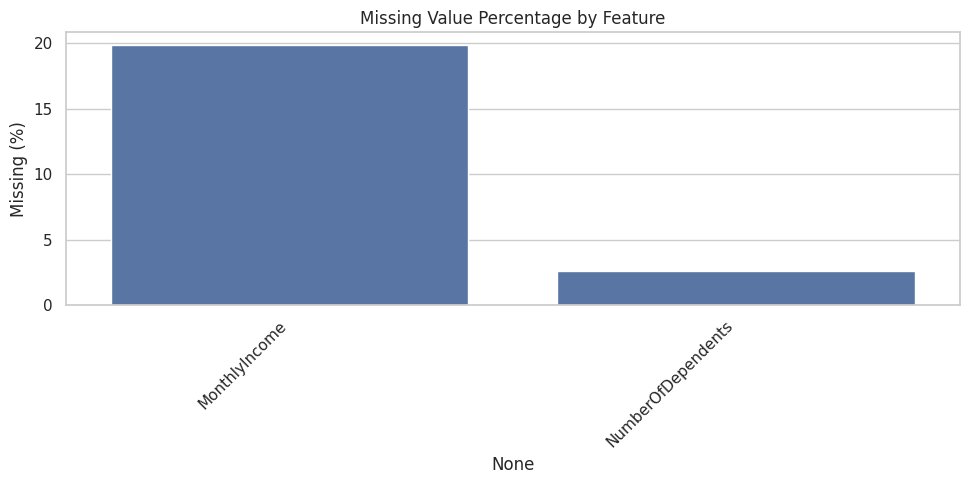

In [ ]:
# 4. Missing Value Analysis

# Count missing values per column
missing_counts = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_df = pd.DataFrame(
    {"missing_count": missing_counts, "missing_percent": missing_percent}
).sort_values(by="missing_percent", ascending=False)

print("Missing values per column (sorted by percentage):")
display(missing_df)

# Bar plot of missing percentages for columns with any missing values
missing_nonzero = missing_df[missing_df["missing_percent"] > 0]

plt.figure(figsize=(10, 5))
if not missing_nonzero.empty:
    if HAS_SEABORN:
        import seaborn as sns

        sns.barplot(x=missing_nonzero.index, y="missing_percent", data=missing_nonzero)
    else:
        plt.bar(missing_nonzero.index, missing_nonzero["missing_percent"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing (%)")
    plt.title("Missing Value Percentage by Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")


Missing value analysis

1. Extent and location of missing values

The missing value analysis shows that missingness is highly concentrated in two variables:

•	MonthlyIncome: 29,731 missing values (≈ 19.8%)

•	NumberOfDependents: 3,924 missing values (≈ 2.6%)

All other variables, including the target SeriousDlqin2yrs, have no missing values.

2. Variables with the most missing values

•	MonthlyIncome clearly has the most missing data and represents a material modeling concern.

•	NumberOfDependents has relatively minor missingness and is not problematic.

3. Should any variables be dropped?

•	Although MonthlyIncome has nearly 20% missing values, it is a core predictor in credit risk and discarding it would likely remove important signal.

•	NumberOfDependents has low enough missingness that simple imputation is sufficient.

4. Is missingness informative?

Yes — especially for MonthlyIncome.

From a credit-risk perspective, missing income is unlikely to be missing completely at random. It may reflect:
•	Unstable or informal employment
•	Lower documentation quality
•	Financial stress or strategic non-disclosure.
As a result, the fact that income is missing may itself carry predictive information about default risk. But this model does not include a missingness indicator.

5. Imputation strategies

NumberOfDependents

•	Method: Median imputation

•	Rationale: Low missingness, limited predictive impact, likely close to MCAR (Missing Completely At Random)

•	Missingness indicator: Not included in this model.

MonthlyIncome

•	Method: Two-part strategy

1.	Median imputation for missing values

2.	Optional: Creation of a missingness indicator (MonthlyIncome_missing). Not included in this model.

•	Rationale: Preserves sample size while allowing the model to learn from both income level and income non-reporting

This approach aligns with industry-standard PD (Probability of Default) modeling practices and avoids both information loss and bias from deletion.


In [ ]:
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


Numeric feature columns used for plots:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


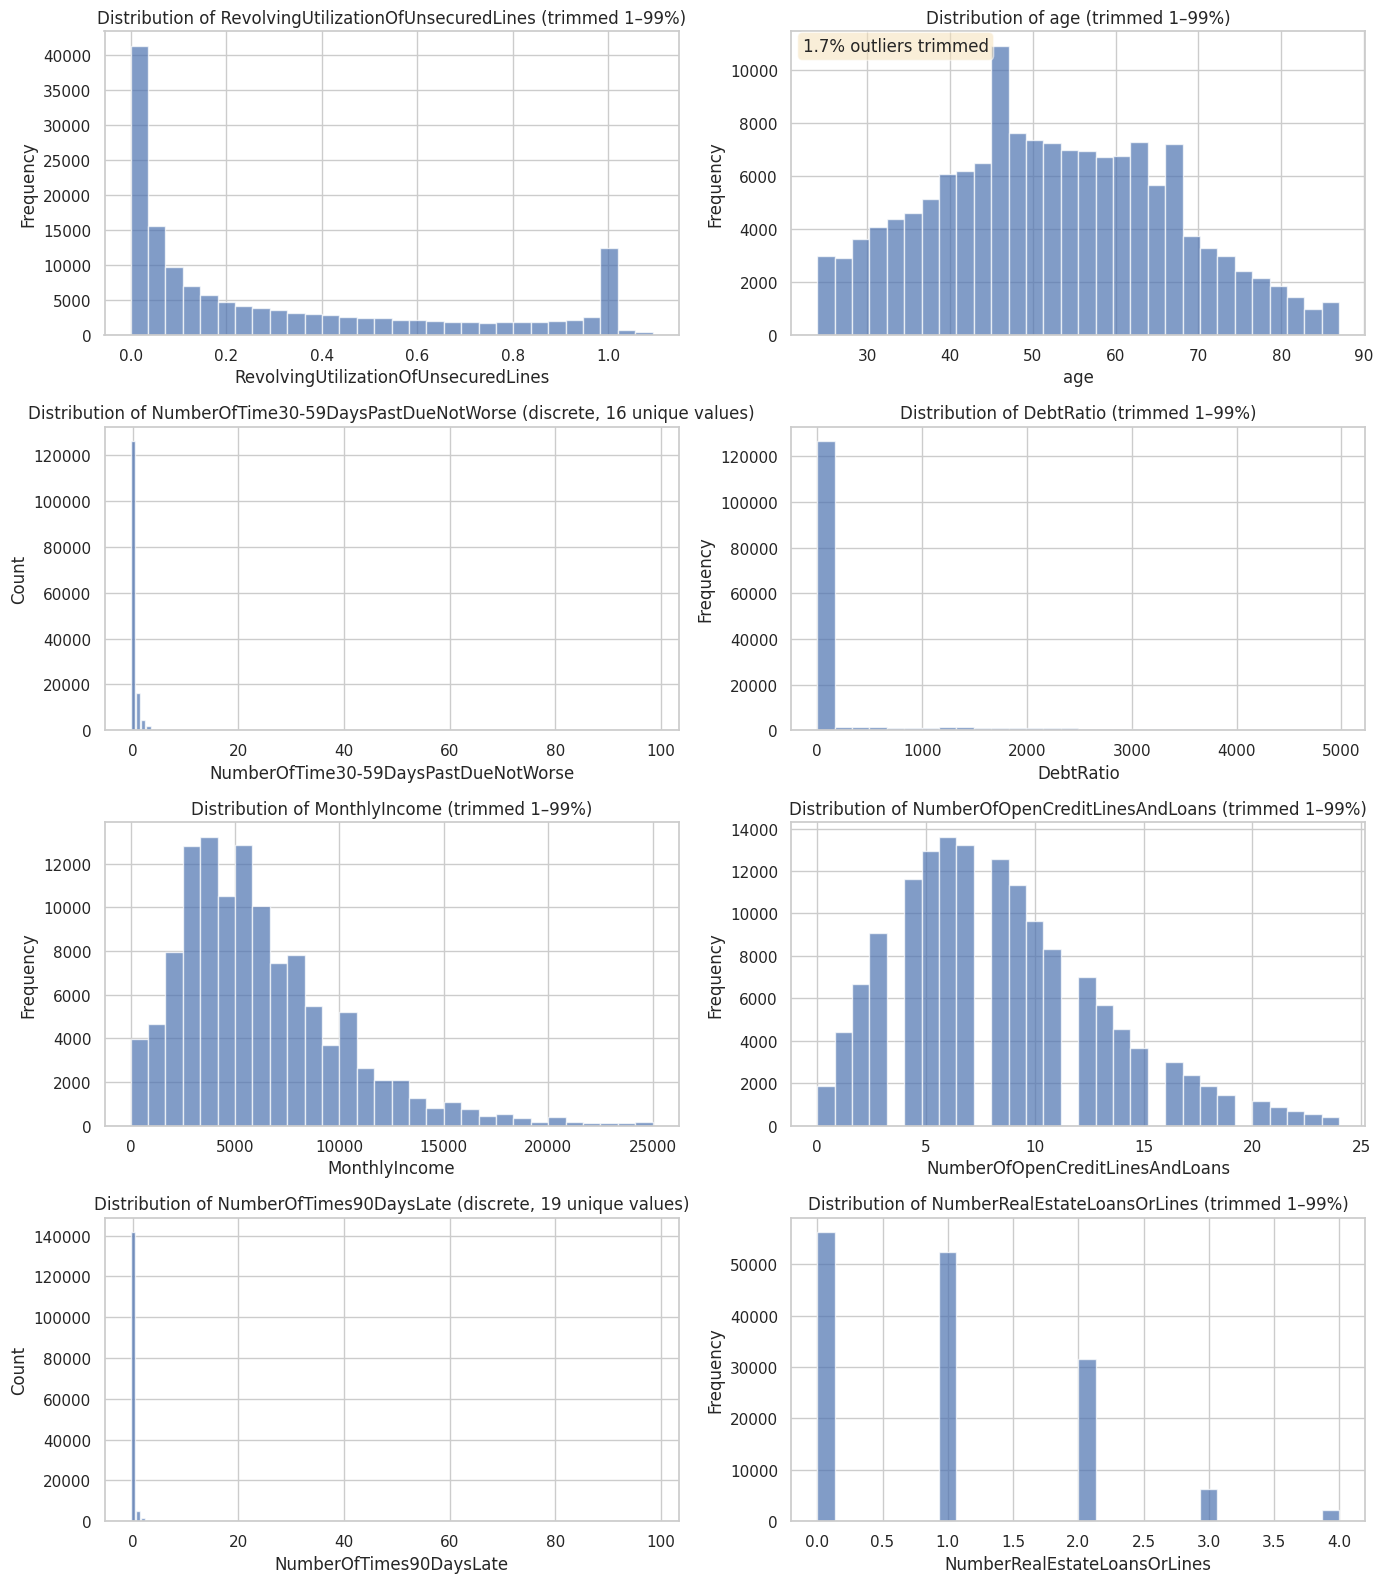

In [ ]:
HAS_SEABORN = False
import math

df_plot = df
# Select numeric columns (excluding the target if desired)
numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()

if TARGET_COL in numeric_cols:
    numeric_feature_cols = [col for col in numeric_cols if col != TARGET_COL]
else:
    numeric_feature_cols = numeric_cols

print("Numeric feature columns used for plots:")
print(numeric_feature_cols)

max_plots = min(8, len(numeric_feature_cols))
cols_to_plot = numeric_feature_cols[:max_plots]

ncols = 2
nrows = math.ceil(max_plots / ncols) if max_plots > 0 else 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, cols_to_plot):
    values = df_plot[col].dropna()
    n_unique = values.nunique()

    # Treat low-cardinality numeric variables as discrete
    if n_unique <= 20:
        # Discrete variable: bar plot of value counts
        value_counts = values.value_counts().sort_index()
        ax.bar(value_counts.index, value_counts.values, alpha=0.7)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.set_title(f"Distribution of {col} (discrete, {n_unique} unique values)")
    else:
        # Continuous variable: trim extremes to focus on bulk of the data
        q1, q99 = values.quantile([0.01, 0.99])
        values_trimmed = values[(values >= q1) & (values <= q99)]

        if HAS_SEABORN:
            import seaborn as sns

            # Let seaborn choose bins automatically
            sns.histplot(values_trimmed, kde=False, ax=ax, bins="auto")
        else:
            # Fallback: simple histogram with a reasonable bin count
            ax.hist(values_trimmed, bins=30, alpha=0.7)

        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
        ax.set_title(f"Distribution of {col} (trimmed 1–99%)")

        # Optional: annotate if many points were trimmed as outliers
        outliers_pct = ((values < q1) | (values > q99)).sum() / len(values) * 100
        if outliers_pct > 1:
            ax.text(
                0.02,
                0.98,
                f"{outliers_pct:.1f}% outliers trimmed",
                transform=ax.transAxes,
                va="top",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
            )

# Hide any unused subplots
for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### variable distributions are inspected

These plots are used to understand skewness, concentration at zero, and unusually heavy tails in the predictors. That matters because credit variables often require capping, scaling, or careful interpretation before they are suitable for a stable PD model.

Categorical-like columns (heuristic):
['SeriousDlqin2yrs', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']


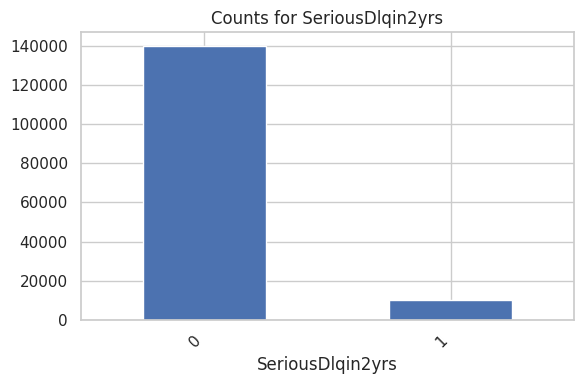

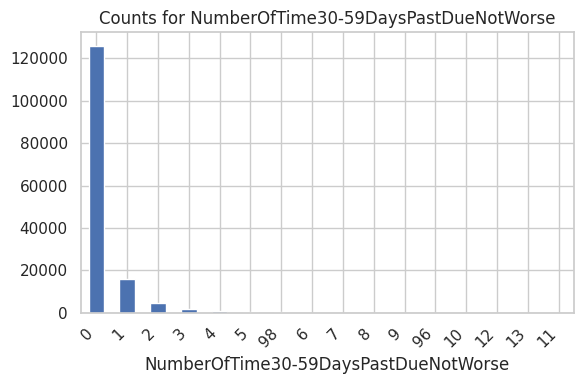

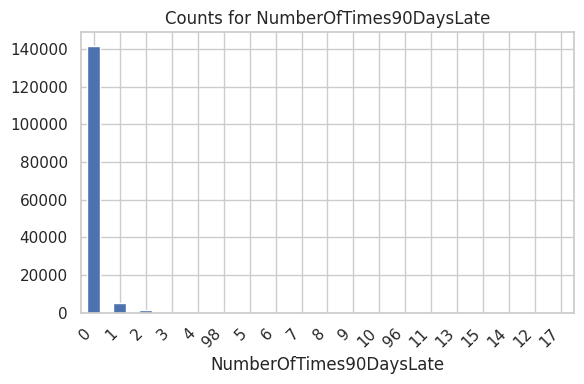

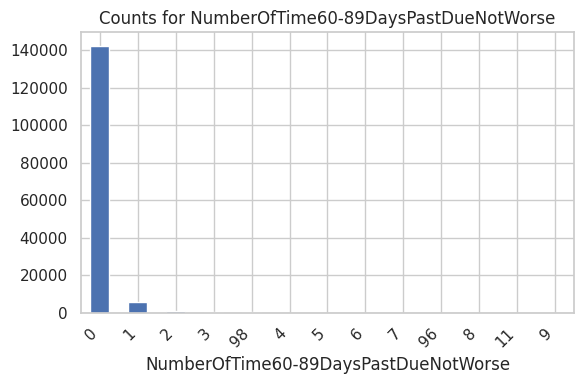

In [ ]:
# 5.1 (Optional) Distribution Plots for Categorical-Like Variables

# Heuristic: low-cardinality integer or object columns
cat_like_cols = [
    col
    for col in df.columns
    if (df[col].dtype == "object")
    or (pd.api.types.is_integer_dtype(df[col]) and df[col].nunique() < 20)
]

print("Categorical-like columns (heuristic):")
print(cat_like_cols)

for col in cat_like_cols:
    plt.figure(figsize=(6, 4))
    if HAS_SEABORN:
        import seaborn as sns

        sns.countplot(x=col, data=df)
    else:
        df[col].value_counts().plot(kind="bar")
    plt.title(f"Counts for {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


**Variable Distribution Interpretation**

**Heavily skewed variables and long tails**

*Several variables exhibit strong right skewness and long tails.*
RevolvingUtilizationOfUnsecuredLines, DebtRatio, and MonthlyIncome all show heavy right tails even after trimming extreme values, indicating the presence of a small number of observations with disproportionately large values. In addition, the delinquency count variables (NumberOfTime30–59DaysPastDueNotWorse, NumberOfTime60–89DaysPastDueNotWorse, and NumberOfTimes90DaysLate) are highly zero-inflated, with the vast majority of observations at zero and a small number of extreme counts.

**Variables with predictive structure or clear patterns**

The delinquency count variables display clear, discrete patterns that are likely to be strongly predictive of the target. The sharp spike at zero versus positive counts suggests a natural separation between borrowers with no delinquency history and those with prior payment problems. RevolvingUtilizationOfUnsecuredLines also shows meaningful structure, with mass near zero and near one, consistent with different borrowing behaviors that may be associated with default risk. Age shows a smoother distribution, suggesting more gradual effects rather than sharp thresholds.

The baseline logistic regression model uses standardized continuous predictors without logarithmic transformations or binning, meaning the model relies on the raw feature relationships rather than scorecard-style discretization.

**Implications for feature engineering and model design**

These distributional characteristics suggest that feature engineering should focus on handling skewness, zero inflation, and extreme values. Capping is appropriate for highly skewed variables. Overall, these observations motivate the use of models that can accommodate nonlinearity and imbalance (such as tree-based methods) or careful preprocessing when using linear or parametric models.


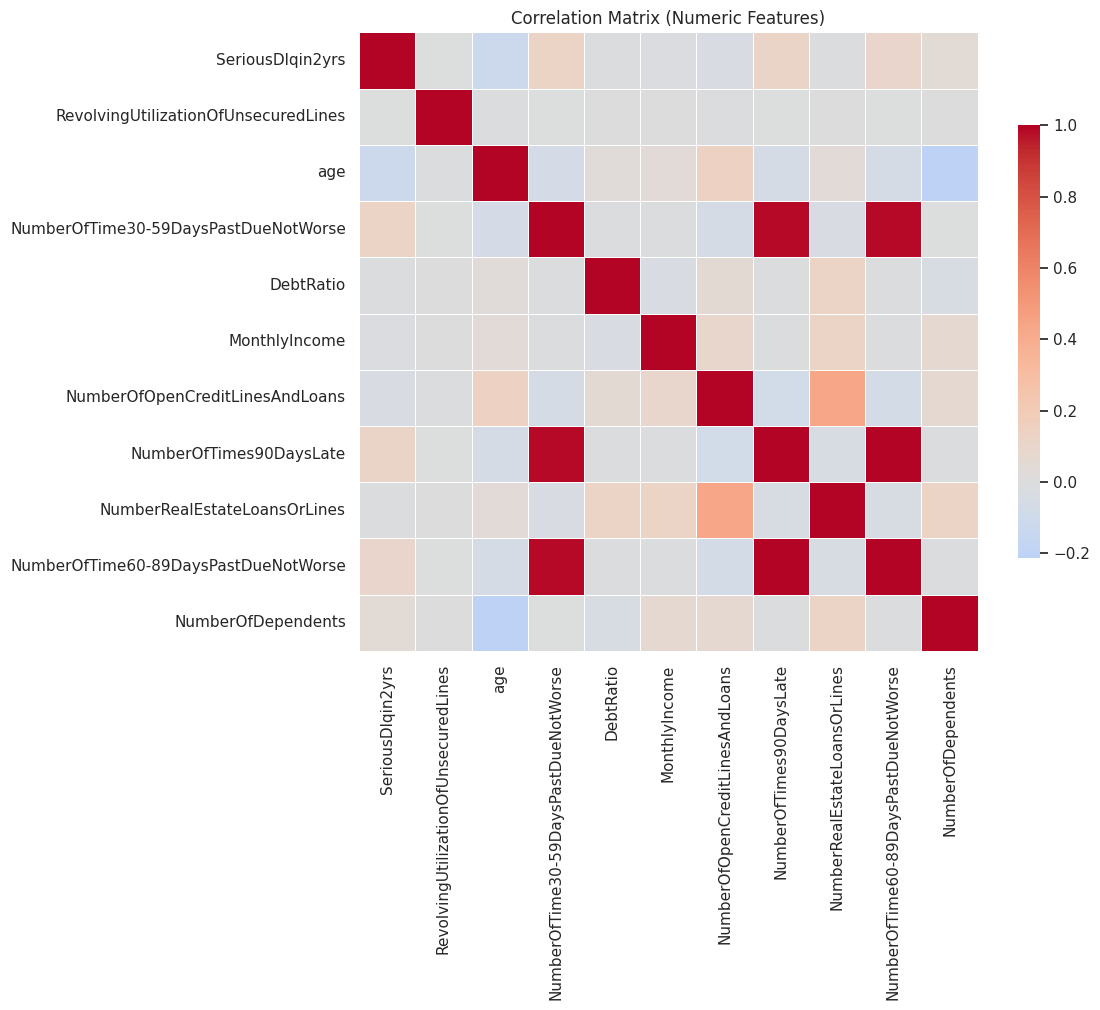

Correlation of numeric features with the target:


,SeriousDlqin2yrs
NumberOfTime30-59DaysPastDueNotWorse,0.125587
NumberOfTimes90DaysLate,0.117175
NumberOfTime60-89DaysPastDueNotWorse,0.102261
NumberOfDependents,0.046048
RevolvingUtilizationOfUnsecuredLines,-0.001802
NumberRealEstateLoansOrLines,-0.007038
DebtRatio,-0.007602
MonthlyIncome,-0.019746
NumberOfOpenCreditLinesAndLoans,-0.029669
age,-0.115386


In [ ]:
HAS_SEABORN = True
# 6. Correlation Matrix

# Correlation matrix for numeric variables
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
if HAS_SEABORN:
    import seaborn as sns

    sns.heatmap(
        corr_matrix,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.7},
    )
else:
    plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
    plt.colorbar(shrink=0.7)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

# Correlation of features with the target
if TARGET_COL in corr_matrix.columns:
    target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL)
    print("Correlation of numeric features with the target:")
    display(target_corr.sort_values(ascending=False))
else:
    print(f"Target column '{TARGET_COL}' not in correlation matrix.")


**Correlation structure among numeric variables**

The correlation matrix reveals clear clusters of highly correlated variables, particularly among the delinquency count features. NumberOfTime30–59DaysPastDueNotWorse, NumberOfTime60–89DaysPastDueNotWorse, and NumberOfTimes90DaysLate exhibit very strong positive correlations with each other, indicating that they capture closely related aspects of borrower payment behavior. This suggests a substantial degree of multicollinearity within this group. Other variables, such as MonthlyIncome, DebtRatio, and RevolvingUtilizationOfUnsecuredLines, show relatively weak correlations with most features, indicating that they contribute more independent information.

**Variables most related to the target**

The variables most strongly correlated with the target SeriousDlqin2yrs are the delinquency count measures. In particular, NumberOfTime30–59DaysPastDueNotWorse, NumberOfTimes90DaysLate, and NumberOfTime60–89DaysPastDueNotWorse show the highest positive correlations with default, confirming that prior payment behavior is a key driver of credit risk. Age exhibits a moderate negative correlation with the target (As age increases, the probability of serious delinquency decreases), suggesting that younger borrowers are more likely to experience serious delinquency. Other variables, such as income, debt ratio, and credit line counts, show weaker linear correlations with the target, though they may still be predictive through nonlinear effects or interactions.

**Multicollinearity considerations**

The strong correlations among delinquency count variables indicate a potential multicollinearity risk, particularly for linear models. Including all delinquency counts simultaneously in a logistic regression may lead to unstable coefficient estimates and inflated standard errors. This motivates either feature selection, dimensionality reduction, or aggregation (e.g., combining delinquency counts into a summary measure). In contrast, tree-based models are less sensitive to multicollinearity and can naturally select among correlated predictors during the splitting process.

**Implications for feature selection**

Feature selection should prioritize delinquency history variables due to their strong association with the target while avoiding redundancy. One approach is to retain the most informative delinquency measure or to engineer a composite feature capturing overall delinquency severity. Variables with low pairwise correlation to the target should not be discarded solely on that basis, as weak linear correlation does not preclude nonlinear predictive power.

**Implications for model choice**

The observed correlation structure favors different modeling strategies depending on the objective. Logistic regression requires careful handling of correlated predictors through regularization, variable selection, or feature aggregation to ensure interpretability and numerical stability. Tree-based models, by contrast, can accommodate correlated inputs and nonlinear relationships more naturally, making them well suited for this data without extensive preprocessing. As a result, correlation analysis supports the use of regularized linear models for interpretability and tree-based methods for flexibility and predictive performance.




### outliers are checked separately

Extreme values can destabilize a logistic regression and can also distort interpretations of borrower risk. This block helps justify whether winsorization or percentile capping is needed before the model is estimated.

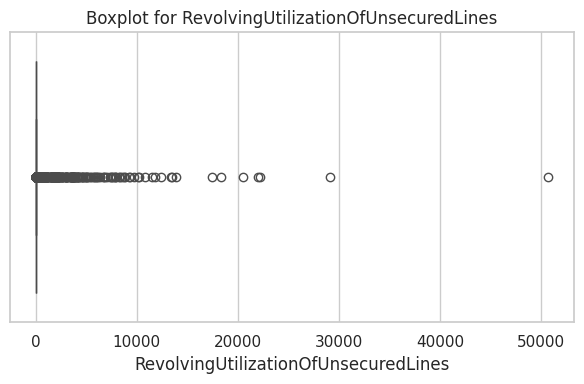

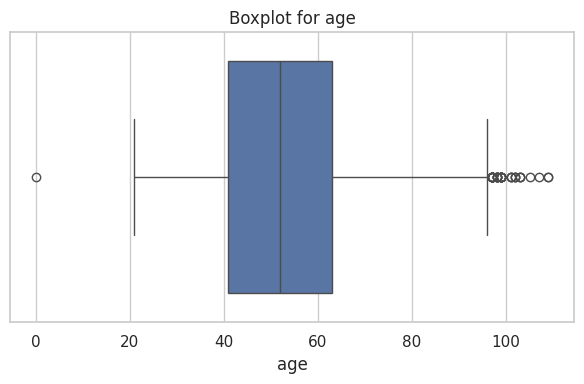

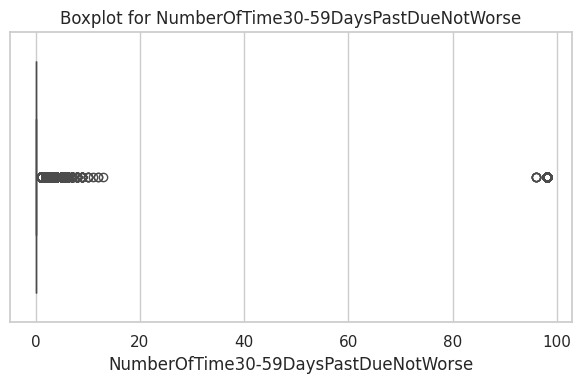

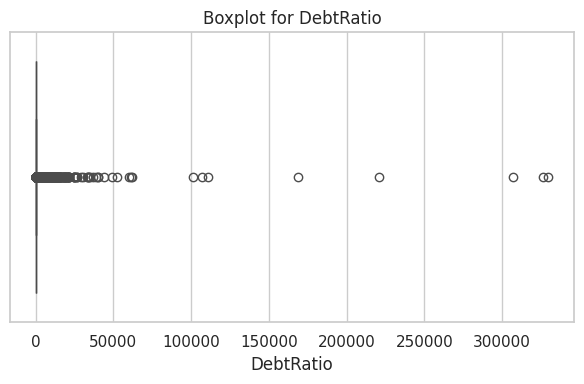

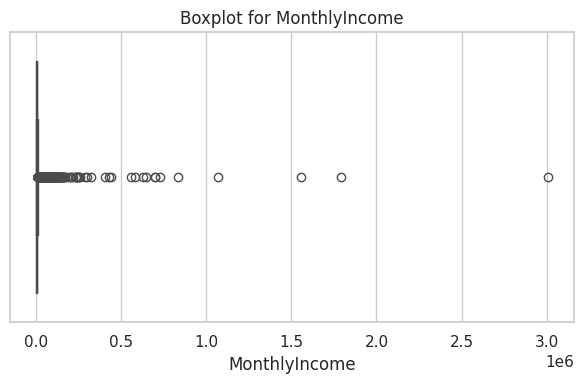

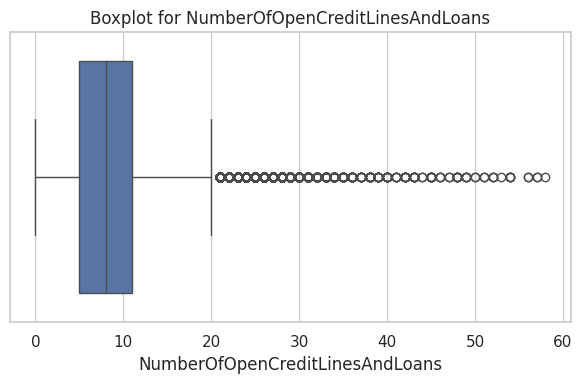

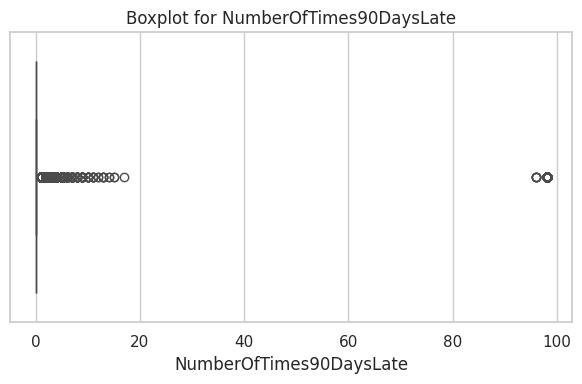

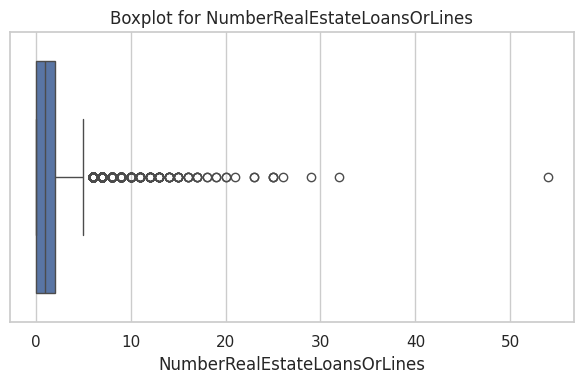

In [ ]:
# 7. Basic Outlier Inspection

# Choose a small set of important numeric features to inspect
# For now, we can reuse the first few numeric features
outlier_cols = cols_to_plot  # or manually specify key columns

for col in outlier_cols:
    plt.figure(figsize=(6, 4))
    if HAS_SEABORN:
        import seaborn as sns

        sns.boxplot(x=df[col])
    else:
        plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot for {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


**Summary decision**

Overall, extreme values are treated through capping rather than deletion, preserving information content while improving model stability, interpretability, and fairness.

**Identification of extreme outliers**

Visual inspection using boxplots reveals extreme right-tail outliers in several numeric variables.
RevolvingUtilizationOfUnsecuredLines, DebtRatio, and MonthlyIncome exhibit particularly severe skewness, with a small number of observations taking values orders of magnitude larger than the bulk of the data. The delinquency count variables (NumberOfTime30–59DaysPastDueNotWorse, and NumberOfTimes90DaysLate) are highly zero-inflated with rare but extreme values (e.g., very large counts of late payments). In contrast, age shows relatively mild outliers at the upper end, which appear plausible and consistent with real borrower ages.

**Data errors versus genuine rare events**

The extreme values observed do not appear to be obvious data entry errors (such as negative values or impossible ages) but rather represent genuine rare events. For example, extremely high utilization or debt ratios may correspond to borrowers under severe financial stress, and large delinquency counts reflect repeated payment failures. As such, these outliers contain meaningful risk information and should not be indiscriminately removed.

**Proposed treatment by variable**

•	RevolvingUtilizationOfUnsecuredLines
Treatment: Cap or winsorize at an upper percentile (e.g., 99th).
Rationale: Extremely large values dominate scale and can destabilize linear models, while capping preserves rank ordering and risk signal.
•	DebtRatio
Treatment: Winsorization.
Rationale: Heavy right skew makes raw values difficult to interpret and model linearly;
•	MonthlyIncome
Treatment: Capping.
Rationale: Income is highly skewed, and extreme values are not proportionally informative.
•	Delinquency count variables
Treatment: Capping.
Rationale: Risk increases sharply once delinquency occurs, but differences among very high counts add limited incremental information and may introduce noise.
•	Age
Treatment: Leave unchanged.
Rationale: Outliers are plausible and age effects are typically monotonic rather than extreme-driven.

**Conceptual implications of outlier treatment**

Outliers in credit data often represent high-risk individuals, not mistakes. Removing such observations could disproportionately exclude vulnerable borrowers and bias the model toward lower-risk populations, raising fairness concerns. Capping extreme values retains these borrowers while preventing a small number of observations from exerting undue influence on parameter estimation.

**Impact on modeling objectives**

•	Predictive performance:
Capping reduces variance and improve generalization, particularly for logistic regression and other parametric models.

•	Interpretability:
More stable and interpretable coefficients, supporting clearer risk narratives.

•	Fairness:
Avoiding row deletion ensures that high-risk but legitimate borrowers remain represented in the training data.

Tree-based models are generally more robust to extreme values and may require less aggressive treatment; however, consistent preprocessing supports comparability across modeling approaches.

**Model Type Justification**

**Candidate model types considered**

For this credit default prediction problem, the primary model families considered are logistic regression, decision trees, and tree-based ensemble methods such as random forests and gradient boosting. These model types are well suited to binary classification problems with structured tabular data and are commonly used in credit risk applications.

Given the structured nature of the data, the presence of strong class imbalance, and the need for interpretability and stability, ** logistic regression is the preferred primary model for this problem. It provides transparent, well-understood probability estimates that align with regulatory expectations and support clear reasoning about risk drivers, fairness, and model behavior.** Tree-based models, including random forests and gradient boosting, are also considered as complementary or challenger models because they naturally capture nonlinear relationships and interaction effects present in credit data. However, their greater complexity and reduced transparency make them less suitable as sole production models in a regulated setting without additional governance and explainability controls.

**Weaknesses / risks of logistic regression and remediation to consider:**

Logistic regression assumes a linear relationship between predictors and the log-odds of default, which may not fully capture nonlinear effects or threshold behavior present in variables such as utilization ratios or delinquency counts. It is also sensitive to multicollinearity and extreme values, **requiring careful preprocessing, and feature selection.**

**Assumptions (Data preparation and model design)**

Assumptions need to be explicit, testable, and regulator-friendly

•	Representativeness: The dataset is assumed to be broadly representative of the target borrower population, with monitoring planned via summary statistics and population stability measures.

•	Stationarity: Relationships between predictors and default are assumed to be reasonably stable over time, with periodic backtesting and revalidation used to detect drift.

•	Missingness: Imputation methods and missingness indicators are assumed not to introduce material bias, and changes in missingness patterns will be monitored.

•	Outliers: Extreme values are treated as genuine high-risk observations rather than errors, with capping or transformation used to limit undue influence while preserving signal.

•	Model form: The planned logistic regression assumes approximate linearity in the log-odds after feature engineering, with challenger models used to test for misspecification.

•	Independence: Observations are assumed to be independent at the borrower level, consistent with the dataset structure.

•	Evaluation alignment: Selected evaluation metrics are assumed to reflect the asymmetric costs of credit risk decisions and will be revisited if objectives change.


**Limitations**

The following limitations highlight where the model may fail or behave poorly and motivate ongoing monitoring, validation, and use of challenger models to mitigate risk.

• Data representativeness: The dataset may not fully reflect future borrower populations or economic conditions, which could affect accuracy and fairness if population characteristics shift.

•	Temporal instability: Predictor–default relationships may change over time due to macroeconomic or behavioral shifts, potentially degrading model performance.

•	Feature engineering simplification: Capping may oversimplify relationships and reduce sensitivity to subtle or extreme risk signals.

•	Model form limitations: The reliance on a primarily linear model in log-odds may miss important nonlinearities or interactions present in the data.

•	Multicollinearity: Strong correlations among delinquency variables can reduce coefficient stability and interpretability in linear models.

•	Outlier treatment risk: Capping extreme values may dampen information from the highest-risk borrowers.

•	Operational risks: Deployment effects such as data drift, feedback loops, or threshold misalignment may impact long-term model stability.


# 2. Model Training

**Conceptual Design Summary**

The dataset exhibits characteristics typical of consumer credit risk data, including a highly imbalanced binary target (SeriousDlqin2yrs), strong right-skewness and long tails in utilization, income, and debt-related variables, zero inflation in delinquency counts, and structured but limited missingness. Correlation analysis confirms that prior delinquency measures are the strongest drivers of default risk, while other variables such as income, utilization, and age contribute more subtly through nonlinear or conditional effects. Outliers are interpreted as genuine high-risk observations rather than data errors and are therefore treated through transformation or capping rather than removal to preserve fairness and information content.

Data preparation and feature engineering choices emphasize stability, interpretability, and risk sensitivity. Missing values are handled through imputation, and skewed variables through capping. These steps are designed to make the data compatible with interpretable modeling approaches while preserving key risk signals.

A logistic regression model is favored as the primary modeling framework due to its transparency, stability, and alignment with regulatory and governance expectations. Tree-based models are considered as challenger or benchmarking approaches to assess potential nonlinear effects and validate that key relationships are not being materially missed. Model evaluation is planned around metrics appropriate for rare-event prediction, including recall, precision, PR–AUC, and confusion matrices, rather than overall accuracy.

The design is subject to explicit assumptions regarding data representativeness, temporal stability of relationships, appropriateness of feature engineering choices, and the adequacy of linearity in the log-odds after preprocessing. Limitations include potential non-stationarity, simplification of complex relationships, and operational risks related to deployment and drift. These risks must be mitigated through planned monitoring, revalidation, and use of challenger models. Overall, the proposed conceptual design reflects a balanced approach that prioritizes interpretability, robustness, and defensibility prior to implementation.


## Objective & Validation Framing (SR 11-7 Framework)


* **Business Purpose:** The model estimates Probability of Default (PD) to support binding retail credit decisions (approval/decline, limits, pricing), directly affecting portfolio risk and customer access to credit.

* **High-Impact Classification:** Because the model influences customer-level decisions and financial exposure, it is treated as a high-impact production model under SR 11-7.

* **Outcomes Over Metrics:** Validation must extend beyond statistical measures (e.g., AUC) to evaluate real-world outcomes such as observed default rates, loss performance, and decision impacts.

* **Calibration & Risk Alignment:** Predicted PDs must align with observed default experience to ensure accurate risk measurement and appropriate capital or pricing decisions.

* **Operational Error Assessment:** Validation must analyze false positives and false negatives to understand customer treatment, approval rates, and business trade-offs.

* **Segment-Level Review:** Performance dispersion across segments (e.g., age quartiles) must be assessed to identify potential fairness, disparate impact, or governance concerns.

* **Ongoing Monitoring & Governance:** Model limitations, threshold choices, and outcome disparities must be documented, monitored, and aligned with stated risk appetite to ensure the model remains fit for purpose.

#### Data Split Strategy (Train/Validation/Test) and Leakage Prevention

### the modeling environment is re-established here

This section starts the formal training and validation workflow. The imports are repeated here so the modeling section can stand on its own and be reviewed independently from the earlier exploratory work.

In [ ]:
# 2.1 Import libraries
# Purpose: set up core libraries for data handling, visualization, and modeling.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
)

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Configure plotting style (helps make ROC and other plots easier to read)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

RANDOM_STATE = 42

In [ ]:
# 2.2 Load the training data (cs-training.csv)
# Purpose: read the modeling dataset and perform a quick sanity check.

# DATA_PATH = "/cs-training.csv"  # assumes this notebook is in the same folder as the CSV
#TARGET_COL = "SeriousDlqin2yrs"

# Load data
#df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget value counts:")
print(df[TARGET_COL].value_counts(normalize=True).rename("proportion"))

# Quick peek at the data
df.head()

Dataset shape: (150000, 11)

Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Target value counts:
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### the data split is central to the validation design

This block creates the training, validation, and test samples. The split is the foundation of the entire validation because it gives us a credible out-of-sample benchmark for judging whether the model generalizes beyond the data used to fit it.

In [ ]:
# 2.3 Create train/validation/test splits
# Purpose: define out-of-sample data for testing and (optionally) a validation set for tuning.
#
# Strategy used here:
# - First split off a test set (e.g., 20%) that will only be used for final evaluation.
# - Then split the remaining data into train and validation sets.
# - Use stratification on the target to preserve the positive rate across splits.

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# First split: train_val vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Second split: train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,  # 0.25 of 0.8 = 0.2 overall, so final split is 60/20/20
    random_state=42,
    stratify=y_train_val,
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# Check target rates across splits to confirm stratification
for name, y_split in {
    "train": y_train,
    "validation": y_val,
    "test": y_test,
}.items():
    print(f"\nTarget rate in {name} set:")
    print(y_split.value_counts(normalize=True).rename("proportion"))

Train shape: (90000, 10)
Validation shape: (30000, 10)
Test shape: (30000, 10)

Target rate in train set:
SeriousDlqin2yrs
0    0.933156
1    0.066844
Name: proportion, dtype: float64

Target rate in validation set:
SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64

Target rate in test set:
SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64


* **Split Proportions (60/20/20):** 60% training ensures stable parameter estimation given class imbalance (6.7% defaults), 20% validation supports model tuning and threshold selection, and 20% test provides a fully independent holdout for final performance confirmation.

* **Validation vs Test Usage:** Validation metrics are used during development for threshold analysis; the test set is reserved for final model selection and reported out-of-sample performance.

* **Stratification Control:** Stratified splitting preserves consistent default rates across train, validation, and test sets, preventing distortion due to imbalance.

* **Leakage Prevention:** Duplicate customers or repeated observations across splits are prevented to ensure true independence between datasets.

* **Temporal Integrity:** Features are constructed using only information available at the decision point, avoiding use of future or outcome-derived information.

* **SR 11-7 Alignment:** The independent holdout test set supports credible out-of-sample claims and aligns with SR 11-7 expectations for independent validation and evidence of model generalization.

## Refit Baseline Model (Logistic Regression) Using Pipeline

In this section we:
- Build a **preprocessing + model** `Pipeline` using `ColumnTransformer`
- Refit a **logistic regression** baseline model on the **training set**

All features in `cs-training.csv` (except the target) are treated as numeric and standardized before modeling.

•	Numeric features are standardized using z-score scaling fitted on the training data and applied consistently to validation data.

•	Missing values are handled using median imputation and extreme values are treated through percentile capping to stabilize model estimation.

### feature definitions are made explicit

Here the analysis identifies which variables enter the model and how they will be treated. Making this explicit helps the reviewer see that the full candidate information set is known before preprocessing and avoids any ambiguity about what the model actually uses.

In [ ]:
# Identify numeric features (all features in this dataset are numeric)
numeric_features = X.columns.tolist()

# Features with missing values
features_with_missing = ["MonthlyIncome", "NumberOfDependents"]

# Create preprocessing pipeline using ColumnTransformer
# This allows different preprocessing for different feature groups

# For features with missing values: impute with median, then scale
# For features without missing values: only scale
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),  # Median imputation for missing values
        ("scaler", StandardScaler()),  # Standardize features (mean=0, std=1)
    ]
)

# Apply the same transformer to all numeric features
# ColumnTransformer will handle missing values appropriately
preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)],
    remainder="drop",  # Drop any columns not specified
)

print("Preprocessing pipeline created:")
print("1. Missing value imputation (median)")
print("2. Feature scaling (standardization)")
print(f"\nFeatures to preprocess: {len(numeric_features)}")

Preprocessing pipeline created:
1. Missing value imputation (median)
2. Feature scaling (standardization)

Features to preprocess: 10


### the pipeline is built this way

This block combines preprocessing and estimation into a single reproducible pipeline. That is important because it reduces leakage risk: imputation and scaling are learned on the training data and then applied consistently to validation and test sets.

In [ ]:
# Create the full pipeline: preprocessing + logistic regression
# This ensures preprocessing is applied consistently to train and validation sets
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                random_state=RANDOM_STATE,
                max_iter=1000,  # Increase iterations for convergence
                class_weight="balanced",  # Handle class imbalance
            ),
        ),
    ]
)

# Train the model
print("Training logistic regression model...")
logistic_pipeline.fit(X_train, y_train)
print("Training completed!")

# Get feature names after preprocessing (for interpretation)
feature_names = numeric_features
print(f"\nModel trained on {len(feature_names)} features")

Training logistic regression model...
Training completed!

Model trained on 10 features


### predictions are generated immediately after fitting

Once the baseline model is trained, we produce both class labels and probabilities. The probabilities are especially important because they support the later analysis of ranking power, calibration, threshold sensitivity, and stress testing.

In [ ]:
# Get predictions and probabilities
y_val_pred = logistic_pipeline.predict(X_val)
y_val_proba = logistic_pipeline.predict_proba(X_val)[:, 1]  # Probability of class 1

# Calculate metrics
auc_score = roc_auc_score(y_val, y_val_proba)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("Logistic Regression Performance Metrics:")
print(f"AUC-ROC: {auc_score:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=["No Default", "Default"]))

Logistic Regression Performance Metrics:
AUC-ROC: 0.7867
Precision: 0.1695
Recall: 0.6564
F1-Score: 0.2694

Classification Report:
              precision    recall  f1-score   support

  No Default       0.97      0.77      0.86     27995
     Default       0.17      0.66      0.27      2005

    accuracy                           0.76     30000
   macro avg       0.57      0.71      0.56     30000
weighted avg       0.92      0.76      0.82     30000



# 3. Validation Results

## Evaluating Train vs Test Performance

- **ROC curves** and **AUC** are computed for both train and test sets.
- **Confusion matrices** are plotted for both train and test.
- **Precision, recall, F1, and accuracy** are calculated on both splits.

- Helper functions are used to keep the code clean and make comparison easier.

### KS is computed in addition to AUC

AUC summarizes ranking quality across all thresholds, but KS is widely used in credit risk because it shows the maximum separation between defaulters and non-defaulters. Including both measures gives a stronger view of discrimination performance.

In [ ]:
def compute_ks(y_true, y_proba, n_bins=100):
    """
    Compute the Kolmogorov–Smirnov (KS) statistic for a binary classifier.
    KS = max difference between cumulative bad rate and cumulative good rate
    over the score distribution.
    """
    data = pd.DataFrame({"y": y_true, "score": y_proba})
    # Sort by score descending: high score = higher predicted risk
    data = data.sort_values("score", ascending=False)
    # Define 'bad' as y=1, 'good' as y=0 (SeriousDlqin2yrs)
    total_bad = (data["y"] == 1).sum()
    total_good = (data["y"] == 0).sum()
    # Bin by score (fine-grained)
    data["bin"] = pd.qcut(
        data["score"].rank(method="first"), q=n_bins, duplicates="drop"
    )
    grouped = data.groupby("bin")
    cum_bad = grouped["y"].sum().cumsum() / total_bad
    cum_good = (grouped["y"].count() - grouped["y"].sum()).cumsum() / total_good
    ks_values = np.abs(cum_bad - cum_good)
    ks_max = ks_values.max()
    ks_cut_bin = ks_values.idxmax()
    # Optional: approximate cutoff score at KS
    ks_cutoff = data.loc[data["bin"] == ks_cut_bin, "score"].min()
    return ks_max, ks_cutoff

In [ ]:
# 4.1 Helper function to evaluate a classifier on a single dataset
# Purpose: compute ROC/AUC, KS, confusion matrix, and classification metrics for a given split.


def evaluate_model(
    pipe, X_split, y_split, dataset_name="dataset", plot_roc=True, plot_cm=True
):
    """Evaluate a fitted Pipeline on a single dataset.
    Returns a dict of metrics and optionally plots ROC curve and confusion matrix.
    """
    # Predicted probabilities for the positive class (SeriousDlqin2yrs = 1)
    y_proba = pipe.predict_proba(X_split)[:, 1]
    # Class predictions at the default 0.5 threshold
    y_pred = pipe.predict(X_split)
    # Core metrics
    auc = roc_auc_score(y_split, y_proba)
    acc = accuracy_score(y_split, y_pred)
    prec = precision_score(y_split, y_pred, zero_division=0)
    rec = recall_score(y_split, y_pred, zero_division=0)
    f1 = f1_score(y_split, y_pred, zero_division=0)
    # KS statistic
    ks, ks_cutoff = compute_ks(y_split, y_proba)
    # ROC curve
    if plot_roc:
        fpr, tpr, _ = roc_curve(y_split, y_proba)
        plt.figure()
        plt.plot(fpr, tpr, label=f"{dataset_name} (AUC = {auc:.3f})")
        plt.plot([0, 1], [0, 1], "k--", label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {dataset_name}")
        plt.legend()
        plt.show()
    # Confusion matrix
    if plot_cm:
        cm = confusion_matrix(y_split, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(values_format="d")
        plt.title(f"Confusion Matrix - {dataset_name}")
        plt.show()
    metrics = {
        "dataset": dataset_name,
        "auc": auc,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "ks": ks,
        "ks_cutoff": ks_cutoff,
    }
    return metrics

### train and test are evaluated side by side

This block calculates the baseline metrics on both the development sample and the holdout sample. The goal is to see whether performance is stable out of sample; if train results are much stronger than test results, that would be an early sign of overfitting.

/tmp/ipykernel_338/2296532502.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby("bin")


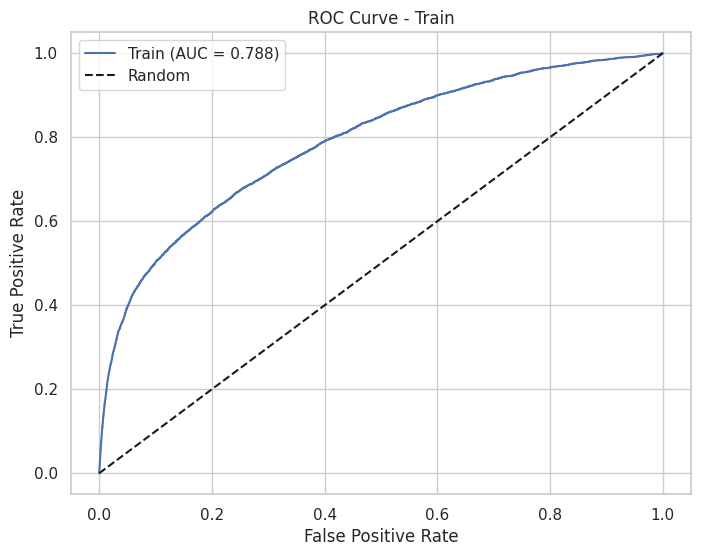

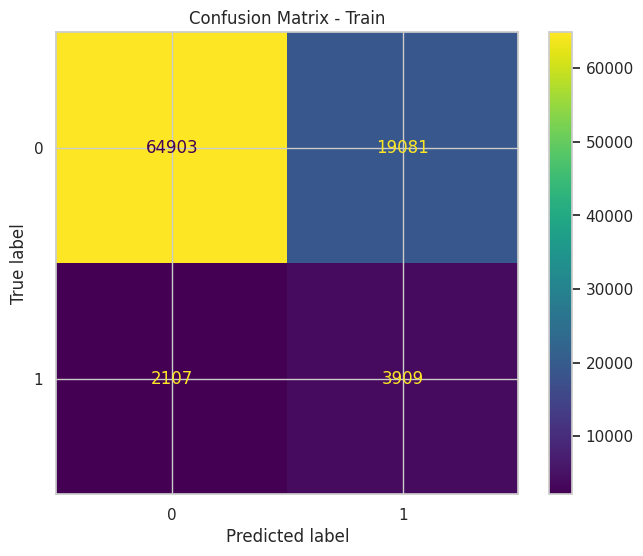

/tmp/ipykernel_338/2296532502.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby("bin")


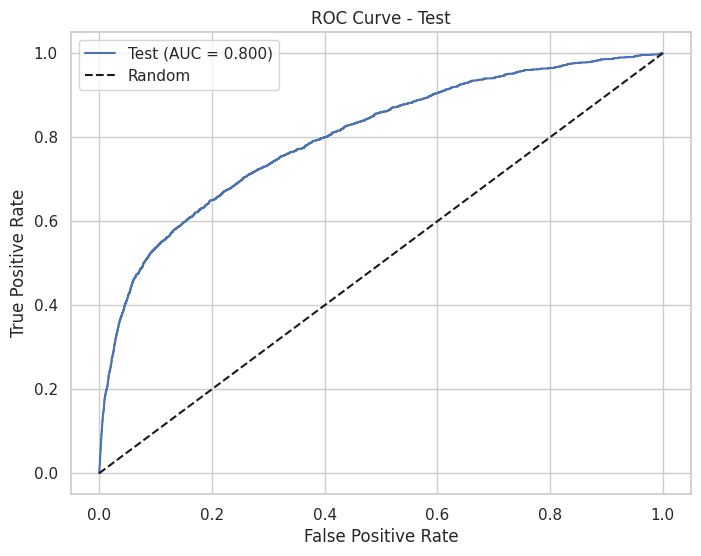

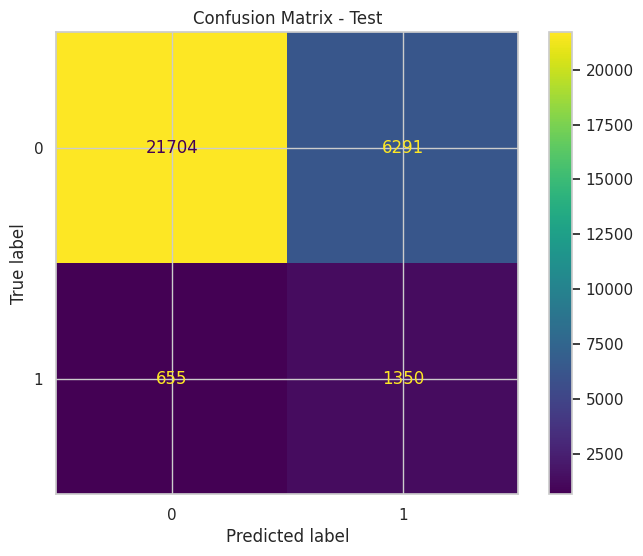

,auc,accuracy,precision,recall,f1,ks,ks_cutoff
dataset,,,,,,,
Train,0.788493,0.764578,0.170030,0.649767,0.269530,0.424428,0.488753
Test,0.800192,0.768467,0.176678,0.673317,0.279909,0.450481,0.506988


In [ ]:
# 4.2 Evaluate baseline model on train and test
# Purpose: compare in-sample vs out-of-sample performance for the logistic regression baseline.

# Evaluate on training data
train_metrics_baseline = evaluate_model(
    logistic_pipeline,
    X_train,
    y_train,
    dataset_name="Train",
)

# Evaluate on test data (held-out)
test_metrics_baseline = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test,
    dataset_name="Test",
)

# Combine metrics into a DataFrame for easier comparison
baseline_results = pd.DataFrame(
    [train_metrics_baseline, test_metrics_baseline]
).set_index("dataset")

baseline_results

## Train–Test Comparison Table & Interpretation

* **Train vs Test Performance:** The model shows **very similar performance on the training and test datasets**, indicating that it generalizes reasonably well and does not show strong signs of overfitting.

* **AUC Comparison:** The **AUC is about 0.79 on the training set and about 0.80 on the test set**, suggesting consistent discrimination power across samples and only a **small train–test gap**.

* **F1 Comparison:** The **F1 scores are also very similar between train and test**, indicating that the balance between precision and recall remains stable across datasets.

* **Overall Gap Assessment:** Because performance does not drop significantly from training to testing, the **train–test gaps appear small**, which is generally a positive validation signal.

* **Confusion Matrix Insight:** The confusion matrices indicate the model is **better at catching defaulters (higher recall)** than at **avoiding false alarms (lower precision)**.

* **Business Implication:** This means the model **captures many risky borrowers but also flags many good borrowers as risky**, which could lead to declining some creditworthy applicants.

* **Deployment Consideration:** While the model shows **reasonable discrimination (AUC ≈ 0.80)** for a baseline credit model, it may still require refinement before full production deployment.

* **Additional Validation Needed:** Before deployment, **calibration testing, segment-level performance analysis, stability testing across time or borrower groups, and a monitoring framework** is needed to ensure the model remains reliable in production.

## Overfitting Analysis: Higher-Variance Model

- A **higher-variance model** (e.g., decision tree) is trained using the same preprocessing.
- **Train vs test performance gaps** are compared between the baseline and higher-variance model.
- Differences explain **overfitting risk**.

The relatively flexible `DecisionTreeClassifier` is the initial higher-variance alternative shown. XGBoost is used further.

### a higher-variance benchmark is useful

The decision tree is included as a challenger not because it is expected to be the final choice, but because it makes overfitting risk easier to diagnose. Comparing it with logistic regression helps show the value of a more transparent model under governance constraints.

In [ ]:
# 6.1 Train a higher-variance model (Decision Tree)
# Purpose: intentionally use a more flexible model to study overfitting.

from sklearn.tree import DecisionTreeClassifier

# Define a relatively flexible decision tree (can easily overfit if not regularized)
high_var_tree = DecisionTreeClassifier(
    max_depth=None,  # no explicit depth limit
    min_samples_leaf=1,  # very small leaves allowed
    random_state=42,
)

# Reuse the same numeric preprocessing
high_var_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="drop",
)

high_var_pipe = Pipeline(
    steps=[
        ("preprocess", high_var_preprocessor),
        ("model", high_var_tree),
    ]
)

# Fit on the same training data as the baseline
high_var_pipe.fit(X_train, y_train)

print("High-variance decision tree fitted.")

High-variance decision tree fitted.


/tmp/ipykernel_338/2296532502.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby("bin")


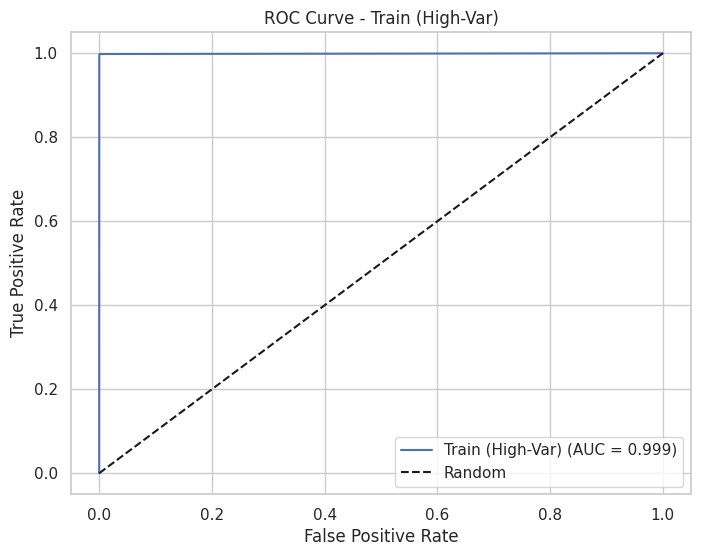

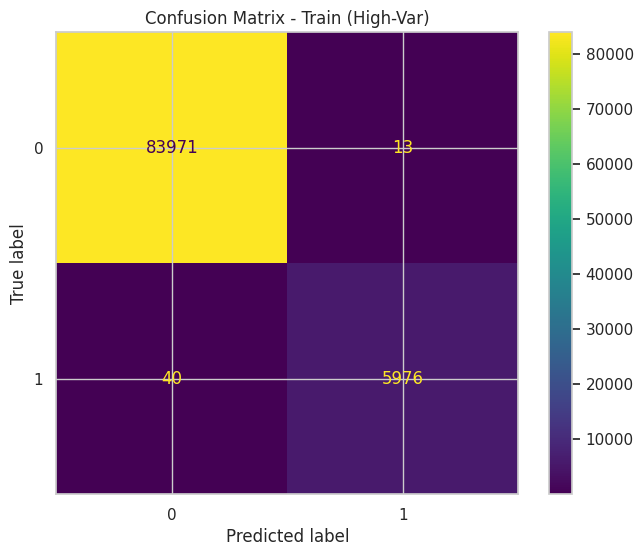

/tmp/ipykernel_338/2296532502.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby("bin")


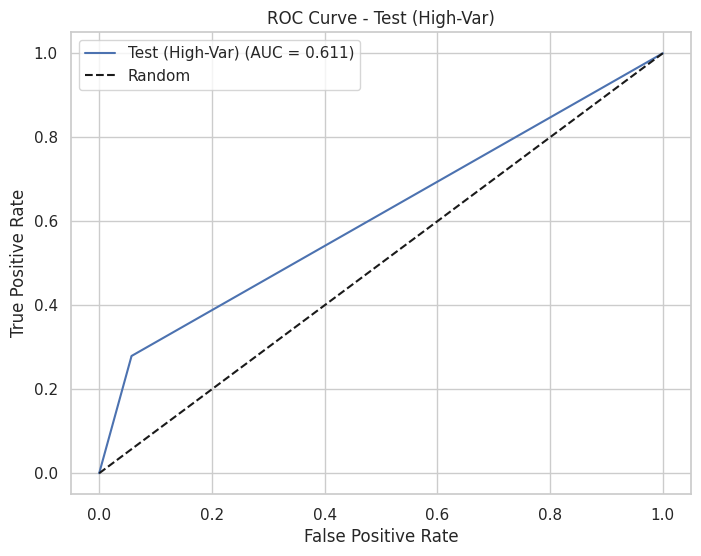

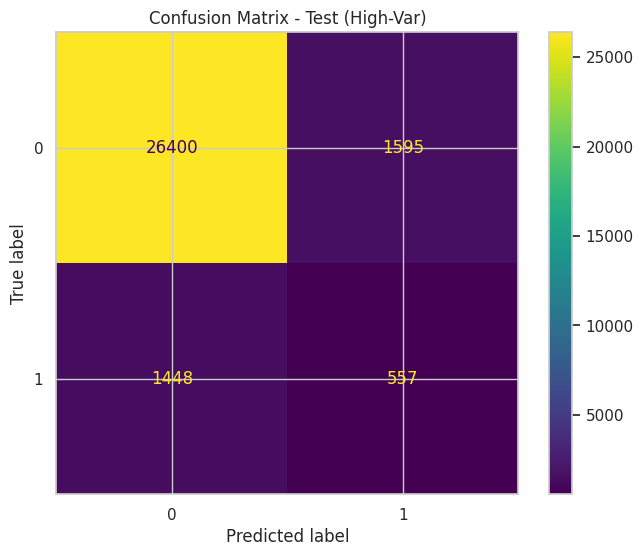

,auc,accuracy,precision,recall,f1,ks,ks_cutoff
dataset,,,,,,,
Train (High-Var),0.999018,0.999411,0.997829,0.993351,0.995585,0.994659,0.0
Test (High-Var),0.610905,0.898567,0.258829,0.277805,0.267982,0.218920,0.0


In [ ]:
# 6.2 Evaluate higher-variance model on train and test
# Purpose: compare how much performance degrades from train to test for the more flexible model.

train_metrics_high_var = evaluate_model(
    high_var_pipe,
    X_train,
    y_train,
    dataset_name="Train (High-Var)",
)

test_metrics_high_var = evaluate_model(
    high_var_pipe,
    X_test,
    y_test,
    dataset_name="Test (High-Var)",
)

high_var_results = pd.DataFrame(
    [train_metrics_high_var, test_metrics_high_var]
).set_index("dataset")

high_var_results

**High-Variance Model Demonstrates Severe Overfitting**

The higher-complexity decision tree model exhibits near-perfect training performance (AUC = 0.999) but substantially lower validation performance (AUC = 0.61).

This large train–test performance gap indicates significant overfitting, where the model captures noise in the training data rather than generalizable patterns.

This result illustrates the importance of model complexity control and proper out-of-sample validation procedures.

### train–test gaps are compared directly

Looking at the train and test metrics in isolation can hide the extent of overfitting. This comparison makes the stability differences explicit and supports the argument that stronger holdout consistency is itself a model risk advantage.

In [ ]:
# 6.3 Compare train–test gaps for baseline vs higher-variance model
# Purpose: quantify overfitting by looking at how much performance drops from train to test.
models_results = {
    "baseline_logreg": baseline_results,
    "high_variance_tree": high_var_results,
}


In [ ]:
models_results

{'baseline_logreg':               auc  accuracy  precision    recall        f1        ks  ks_cutoff
 dataset                                                                        
 Train    0.788493  0.764578   0.170030  0.649767  0.269530  0.424428   0.488753
 Test     0.800192  0.768467   0.176678  0.673317  0.279909  0.450481   0.506988,
 'high_variance_tree':                        auc  accuracy  precision    recall        f1        ks  ks_cutoff
 dataset                                                                                 
 Train (High-Var)  0.999018  0.999411   0.997829  0.993351  0.995585  0.994659        0.0
 Test (High-Var)   0.610905  0.898567   0.258829  0.277805  0.267982  0.218920        0.0}

In [ ]:
# 6.3 Compare train–test gaps for baseline vs higher-variance model
# Purpose: quantify overfitting by looking at how much performance drops from train to test.

metric_cols = ["auc", "accuracy", "precision", "recall", "f1", "ks"]

gap_rows = []
for model_name, df_res in models_results.items():
    row = {"model": model_name}

    # Find the train and test index labels in this result table
    train_idx = [idx for idx in df_res.index if "Train" in idx][0]
    test_idx = [idx for idx in df_res.index if "Test" in idx][0]

    for m in metric_cols:
        # train minus test: large positive values suggest overfitting
        row[f"{m}_gap_train_minus_test"] = (
            df_res.loc[train_idx, m] - df_res.loc[test_idx, m]
        )

    gap_rows.append(row)

gap_table = pd.DataFrame(gap_rows).set_index("model")

print("Train–test gaps (train minus test). Positive values suggest overfitting:")
gap_table

Train–test gaps (train minus test). Positive values suggest overfitting:


,auc_gap_train_minus_test,accuracy_gap_train_minus_test,precision_gap_train_minus_test,recall_gap_train_minus_test,f1_gap_train_minus_test,ks_gap_train_minus_test
model,,,,,,
baseline_logreg,-0.011699,-0.003889,-0.006648,-0.023549,-0.010378,-0.026053
high_variance_tree,0.388113,0.100844,0.739000,0.715546,0.727603,0.775739



**Overfitting Interpretation:**

*Comparison between Logistic Regression and High-Variance models*

• The **high-variance decision tree shows the largest train–test performance gap**, with training AUC = **0.999** but validation AUC dropping to = **0.61**, indicating severe overfitting.

• In contrast, the **logistic regression baseline shows a small train–test gap**, with AUC remaining level,  **0.79 (train)** - **0.80 (test)**, suggesting much better generalization to unseen data.

• The decision tree likely **memorizes patterns specific to the training dataset** rather than learning stable relationships between borrower characteristics and default risk.

• This illustrates a key model risk principle: **more complex models can achieve excellent training performance but fail to generalize if model variance is too high.**

• Although high-variance models may perform better if **properly tuned or regularized**, the current results support selecting **logistic regression due to its stable out-of-sample performance and lower overfitting risk.**

## Robustness performance by age band

### segment-level performance is reviewed

A model can look acceptable in aggregate while performing very differently across subgroups. This block checks performance by age quartile to test robustness and to surface any segment-level outcome differences that may matter for fairness or governance review.

In [ ]:
# 7.1 Example: Segment performance by age quartile on the test set
# Purpose: check whether model performance is stable across simple customer segments.

# We assume 'age' exists in the original df and in X_test indices.
age_test = df.loc[X_test.index, "age"]
age_bins = pd.qcut(age_test, q=4, labels=["Q1 (youngest)", "Q2", "Q3", "Q4 (oldest)"])

segment_results = []

for label in age_bins.unique():
    segment_idx = age_bins[age_bins == label].index
    if len(segment_idx) < 100:
        # Skip very small segments to avoid unstable estimates
        continue

    metrics = evaluate_model(
        logistic_pipeline,
        X_test.loc[segment_idx],
        y_test.loc[segment_idx],
        dataset_name=f"Test - age {label}",
        plot_roc=False,
        plot_cm=False,
    )
    metrics["segment"] = str(label)
    segment_results.append(metrics)

segment_perf = pd.DataFrame(segment_results).set_index("segment")

print("Segment-level performance for baseline model (by age quartile):")
segment_perf[["auc", "accuracy", "precision", "recall", "f1"]]

Segment-level performance for baseline model (by age quartile):


/tmp/ipykernel_338/2296532502.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby("bin")
/tmp/ipykernel_338/2296532502.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby("bin")
/tmp/ipykernel_338/2296532502.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby("bin")
/tmp/ipykernel_338/2296532502.py:17: FutureWarning: The default of observed=False is 

,auc,accuracy,precision,recall,f1
segment,,,,,
Q4 (oldest),0.772272,0.967681,0.294118,0.240964,0.264901
Q3,0.783623,0.915319,0.285945,0.467018,0.354709
Q2,0.769574,0.802998,0.235903,0.634675,0.343960
Q1 (youngest),0.775788,0.404771,0.140443,0.888206,0.242536


**Segment-Level Robustness Assessment (Age Quartiles)**

Segment-level analysis indicates that model discrimination is stable across age quartiles (AUC ≈ 0.77–0.78), suggesting consistent rank-ordering ability across segments. However, classification performance varies materially. The youngest segment (Q1) exhibits very high recall (0.88) but substantially lower precision (0.14), indicating elevated false-positive rates. In contrast, the oldest segment (Q4) demonstrates higher precision (0.29) but very low recall (0.24), implying a greater likelihood of missed defaults.

F1 scores are highest in the middle quartiles (Q2–Q3), reflecting more balanced performance. These findings suggest that while predictive power is stable, the operational impact of the global classification threshold differs significantly across age segments, potentially raising fairness and policy considerations. Further calibration review and threshold sensitivity analysis may be warranted.

## Comparison with ML models

### a machine-learning challenger is included

XGBoost is introduced as a performance benchmark against the baseline logistic model. The purpose is not only to see whether discrimination improves, but also to make the trade-off between predictive lift and governance complexity concrete.

In [ ]:
import xgboost as xgb
# Train XGBoost Classifier (if available)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            xgb.XGBClassifier(
                random_state=RANDOM_STATE,
                max_depth=6,  # Limit depth to prevent overfitting
                n_estimators=100,  # Number of boosting rounds
                learning_rate=0.1,  # Step size shrinkage
                scale_pos_weight=(y_train == 0).sum()
                / (y_train == 1).sum(),  # Handle class imbalance
                eval_metric="logloss",
                use_label_encoder=False,
            ),
        ),
    ]
    )

print("\nTraining XGBoost model...")
xgb_pipeline.fit(X_train, y_train)
print("Training completed!")

# # Evaluate XGBoost
# y_val_pred_xgb = xgb_pipeline.predict(X_val)
# y_val_proba_xgb = xgb_pipeline.predict_proba(X_val)[:, 1]

# auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)
# precision_xgb = precision_score(y_val, y_val_pred_xgb)
# recall_xgb = recall_score(y_val, y_val_pred_xgb)
# f1_xgb = f1_score(y_val, y_val_pred_xgb)

# print("\nXGBoost Performance Metrics:")
# print(f"AUC-ROC: {auc_xgb:.4f}")
# print(f"Precision: {precision_xgb:.4f}")
# print(f"Recall: {recall_xgb:.4f}")
# print(f"F1-Score: {f1_xgb:.4f}")


Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:48:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training completed!


/tmp/ipykernel_338/2296532502.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby("bin")


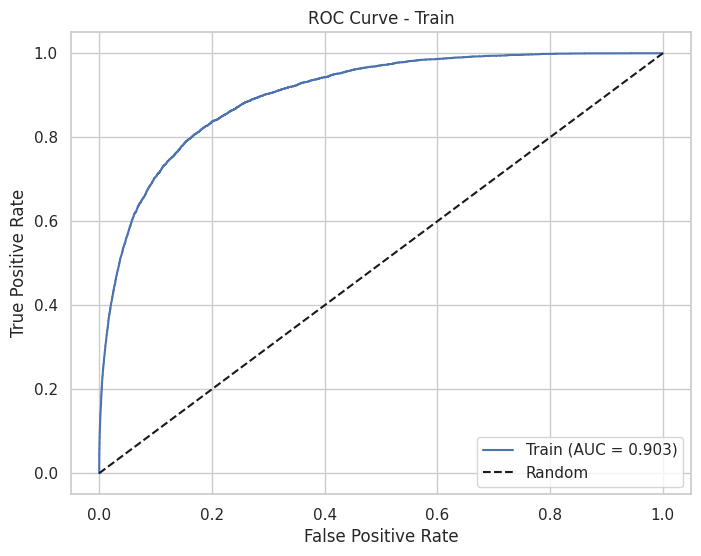

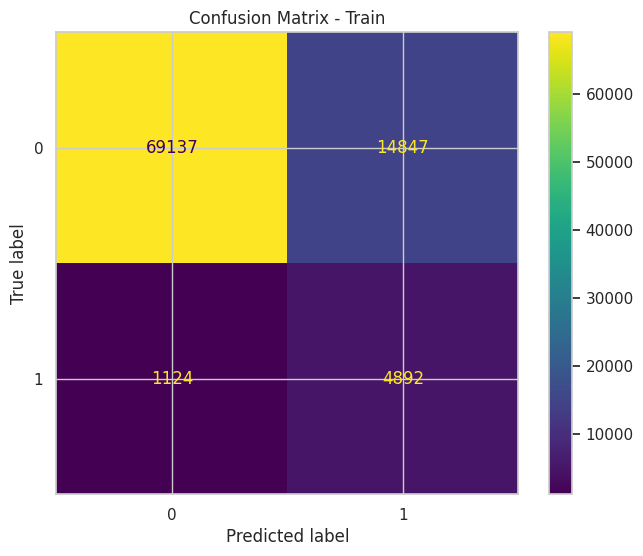

/tmp/ipykernel_338/2296532502.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby("bin")


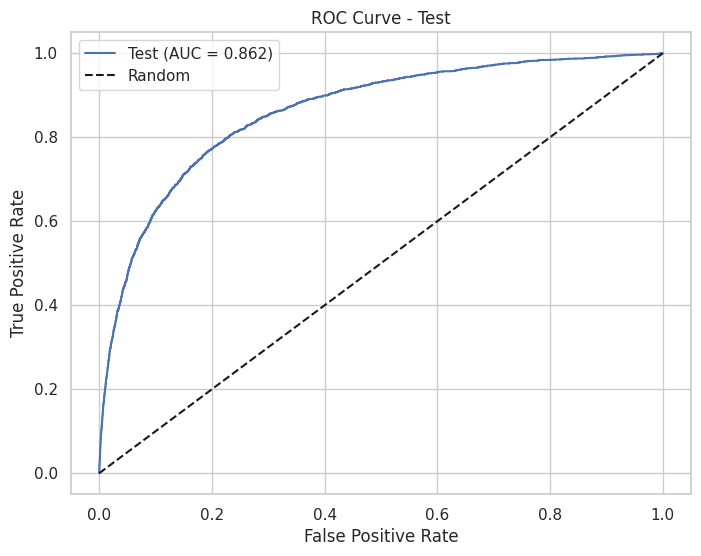

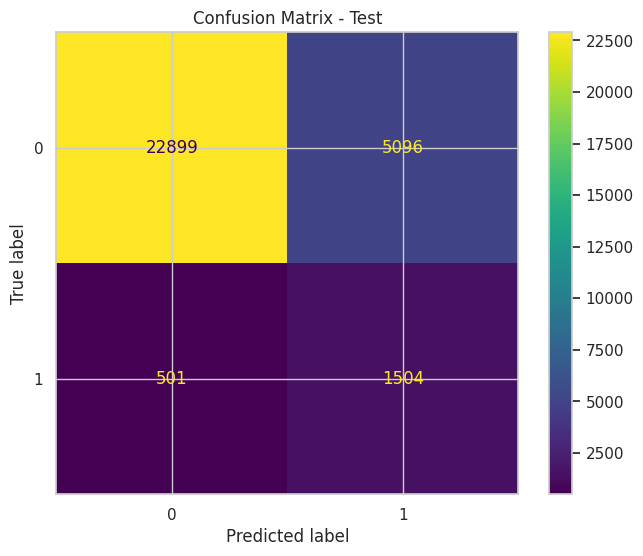

,auc,accuracy,precision,recall,f1,ks,ks_cutoff
dataset,,,,,,,
Train,0.902598,0.822544,0.247834,0.813165,0.379887,0.63723,0.470423
Test,0.861804,0.813433,0.227879,0.750125,0.349564,0.57341,0.470450


In [ ]:
# Evaluate xgb model on train and test
# Purpose: compare in-sample vs out-of-sample performance for the xgboost model.

# Evaluate on training data
train_metrics_xgb = evaluate_model(
    xgb_pipeline,
    X_train,
    y_train,
    dataset_name="Train",
)

# Evaluate on test data (held-out)
test_metrics_xgb = evaluate_model(
    xgb_pipeline,
    X_test,
    y_test,
    dataset_name="Test",
)

# Combine metrics into a DataFrame for easier comparison
xgb_results = pd.DataFrame(
    [train_metrics_xgb, test_metrics_xgb]
).set_index("dataset")

xgb_results

In [ ]:
# Compare train–test gaps for baseline vs ML model
# Purpose: quantify overfitting by looking at how much performance drops from train to test.

models_results_ml = {
    "baseline_logreg": baseline_results,
    "XGBoost": xgb_results,
}

metric_cols = ["auc", "accuracy", "precision", "recall", "f1", "ks"]

gap_rows = []
for model_name, df_res in models_results_ml.items():
    row = {"model": model_name}

    # Find the train and test index labels in this result table
    train_idx = [idx for idx in df_res.index if "Train" in idx][0]
    test_idx = [idx for idx in df_res.index if "Test" in idx][0]

    for m in metric_cols:
        # train minus test: large positive values suggest overfitting
        row[f"{m}_gap_train_minus_test"] = (
            df_res.loc[train_idx, m] - df_res.loc[test_idx, m]
        )

    gap_rows.append(row)

gap_table = pd.DataFrame(gap_rows).set_index("model")

print("Train–test gaps (train minus test). Positive values suggest overfitting:")
gap_table

Train–test gaps (train minus test). Positive values suggest overfitting:


,auc_gap_train_minus_test,accuracy_gap_train_minus_test,precision_gap_train_minus_test,recall_gap_train_minus_test,f1_gap_train_minus_test,ks_gap_train_minus_test
model,,,,,,
baseline_logreg,-0.011699,-0.003889,-0.006648,-0.023549,-0.010378,-0.026053
XGBoost,0.040795,0.009111,0.019955,0.063040,0.030323,0.063819


## Findings Summary & Recommendations

The objective of this analysis was to assess the fitness of a credit risk model designed to predict borrower default and support credit decisioning. Validation was conducted using an out-of-sample testing framework to evaluate predictive performance and identify potential model risk through overfitting diagnostics and segment-level robustness analysis. The baseline logistic regression model demonstrates stable out-of-sample performance, with **AUC = 0.80 and KS = 0.45 on the test sample**, indicating solid discriminatory power. The relatively small performance gap between training and testing results suggests that the model generalizes well and avoids the instability often associated with overly complex models.

To evaluate model complexity risk, a higher-variance decision tree was also tested. While this model achieved **near-perfect training performance (AUC = 0.999)**, its test performance declined sharply (**AUC = 0.61**), clearly indicating severe overfitting. A more advanced **XGBoost challenger model achieved stronger predictive performance (AUC = 0.86, KS = 0.57)** but introduces greater model complexity and governance considerations. Segment analysis across age groups showed consistent ranking performance, although some variation in recall and precision suggests the importance of monitoring model performance across borrower segments.

Based on these findings, the logistic regression model is considered acceptable for use with limitations given its stability, interpretability, and acceptable predictive performance. Recommended next steps include **evaluating probability calibration, implementing population stability monitoring (PSI) in production, and controlling model complexity to mitigate overfitting risk**. These controls will help ensure that model performance remains reliable as borrower characteristics and economic conditions evolve.

# 4. PD Model Stress Testing, Sensitivity, and Interpretability

### the workflow restarts for stress testing

This section moves beyond ordinary holdout validation and asks how the PD model behaves under adverse conditions. Rebuilding the setup here makes the stress-testing workflow self-contained and easier for a reviewer to follow from start to finish.

In [ ]:
# Imports and global settings

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

import joblib

# Optional: tree/boosting model
try:
    from xgboost import XGBClassifier

    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# Optional: Modeva for evaluation / explainability
try:
    import modeva

    MODEVA_AVAILABLE = True
except ImportError:
    MODEVA_AVAILABLE = False

# SHAP for global + local explanations
import shap

# Make plots appear inline in Jupyter
%matplotlib inline

RANDOM_STATE = 42
MODEL_DIR = "models"
BASELINE_MODEL_PATH = os.path.join(MODEL_DIR, "pd_logreg_pipeline.joblib")
TREE_MODEL_PATH = os.path.join(MODEL_DIR, "pd_xgb_pipeline.joblib")

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Modeva available: {MODEVA_AVAILABLE}")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")

Modeva available: False
XGBoost available: True


In [ ]:
# Load data and basic checks

# Read the training data; treat 'NA' as missing values
cs_path = "/content/cs-training.csv"
raw = pd.read_csv(cs_path, na_values=["NA"])

# First column is an index-like ID, drop it
raw = raw.drop(columns=raw.columns[0])

# Target and features
TARGET = "SeriousDlqin2yrs"
feature_cols = [c for c in raw.columns if c != TARGET]

X = raw[feature_cols].copy()
y = raw[TARGET].astype(int)

print("Shape:", X.shape)
print("Target mean (PD):", y.mean().round(4))
print("Columns:", feature_cols)

Shape: (150000, 10)
Target mean (PD): 0.0668
Columns: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [ ]:
# Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target mean:", y_train.mean().round(4))
print("Test target mean:", y_test.mean().round(4))

Train shape: (105000, 10)
Test shape: (45000, 10)
Train target mean: 0.0668
Test target mean: 0.0668


In [ ]:
# Preprocessing and model pipelines (sklearn Pipeline + ColumnTransformer)

# All features in this dataset are numeric, so we use a single numeric pipeline.

numeric_features = feature_cols

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),  # handle missing numeric values
        ("scaler", StandardScaler()),  # scale features for logistic regression
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
    ]
)

# Baseline Logistic Regression PD model
logreg_clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced",
)

logreg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", logreg_clf),
    ]
)

# Optional tree/boosting model (only used if XGBoost is installed)
if XGBOOST_AVAILABLE:
    xgb_clf = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    xgb_pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", xgb_clf),
        ]
    )
else:
    xgb_pipeline = None

In [ ]:
# Train or load baseline models

# Helper to train a pipeline and save it


def train_and_save(pipeline, X_tr, y_tr, path: str, model_name: str):
    """Fit the pipeline and save it to disk if not already present."""
    print(f"Training {model_name} ...")
    pipeline.fit(X_tr, y_tr)
    joblib.dump(pipeline, path)
    print(f"Saved {model_name} to {path}")
    return pipeline


# Logistic regression baseline
if os.path.exists(BASELINE_MODEL_PATH):
    print("Loading existing logistic regression PD model ...")
    logreg_pipeline = joblib.load(BASELINE_MODEL_PATH)
else:
    logreg_pipeline = train_and_save(
        logreg_pipeline,
        X_train,
        y_train,
        BASELINE_MODEL_PATH,
        "logistic regression PD model",
    )

# Optional XGBoost model
if XGBBOOST_AVAILABLE := XGBOOST_AVAILABLE and xgb_pipeline is not None:
    if os.path.exists(TREE_MODEL_PATH):
        print("Loading existing XGBoost PD model ...")
        xgb_pipeline = joblib.load(TREE_MODEL_PATH)
    else:
        xgb_pipeline = train_and_save(
            xgb_pipeline, X_train, y_train, TREE_MODEL_PATH, "XGBoost PD model"
        )
else:
    print("XGBoost not available or not configured. Skipping tree model.")

# Baseline PD predictions on test data
pd_baseline = logreg_pipeline.predict_proba(X_test)[:, 1]
auc_baseline = roc_auc_score(y_test, pd_baseline)

print(f"Baseline logistic regression AUC (test): {auc_baseline:.4f}")

Training logistic regression PD model ...
Saved logistic regression PD model to models/pd_logreg_pipeline.joblib
Training XGBoost PD model ...
Saved XGBoost PD model to models/pd_xgb_pipeline.joblib
Baseline logistic regression AUC (test): 0.7995


### helper functions are defined before scenarios

The stress scenarios all rely on the same summary calculations, so those functions are centralized first. This improves consistency across scenarios and makes the later comparisons easier to trust and reproduce.

In [ ]:
# Helper functions for stress testing and summary statistics

BASELINE_PD = pd_baseline  # keep a copy for convenience

# Risk band threshold for PD (e.g. 10%)
RISK_BAND_THRESHOLD = 0.10


def compute_stress_metrics(pd_base: np.ndarray, pd_stress: np.ndarray, label: str):
    """Compute avg ΔPD, band migrations, and rank stability under stress."""
    delta_pd = pd_stress - pd_base
    avg_delta = float(delta_pd.mean())

    # Proportion above risk band threshold before and after stress
    base_above = float((pd_base > RISK_BAND_THRESHOLD).mean())
    stress_above = float((pd_stress > RISK_BAND_THRESHOLD).mean())

    # Rank stability (Spearman correlation)
    corr, _ = spearmanr(pd_base, pd_stress)

    metrics = {
        "scenario": label,
        "avg_delta_pd": avg_delta,
        "pct_above_threshold_baseline": base_above,
        "pct_above_threshold_stress": stress_above,
        "spearman_rank_corr": corr,
    }

    return metrics


def plot_pd_distribution(pd_base: np.ndarray, pd_stress: np.ndarray, title: str):
    """Plot PD distributions before and after stress using simple matplotlib histograms."""
    plt.figure(figsize=(6, 4))
    plt.hist(pd_base, bins=50, alpha=0.6, label="Baseline", density=True)
    plt.hist(pd_stress, bins=50, alpha=0.6, label="Stressed", density=True)
    plt.xlabel("PD")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
pd_baseline.mean(), y.mean()

(np.float64(0.41187014014110385), np.float64(0.06684))

## Baseline PD model: quick diagnostic

AUC of 0.8 demonstrates that the model reasonably discriminates between defaults and non‑defaults.

Any borrower whose predicted probability of default exceeds 10% is counted as being in the high-risk category.

The model would need to be calibrated, with an average predicted PD of approximately 41% compared with an observed default rate of about 6.7%.

This likely reflects the use of class weighting during model training, which improves default detection but distorts probability calibration.

The 10% PD threshold defines a high-risk band used to measure portfolio migration under stress; we track the proportion of borrowers whose predicted default probability exceeds this level before and after stress to evaluate PD sensitivity and ranking stability.

Banks need calibration because PD feeds into capital and accounting models:

Expected loss

Expected Loss = PD × LGD × EAD

CECL accounting

IFRS 9 provisions

Stress testing

If PDs are miscalibrated, loss forecasts become wrong.

How to check calibration:

Calibration plot (reliability curve)
Compare predicted PD vs actual default rate by decile.

This connects to stress testing which checks: Average PD change under stress, risk band migration (>10%), rank stability.

“If macro stress increases PDs, are the stressed PDs still calibrated to realistic default rates?”

That’s the next step in model validation.

Beyond ranking performance (AUC/KS), Calibration diagnostics assess whether predicted probabilities of default correspond to observed default frequencies across risk groups, ensuring that PD estimates remain meaningful for credit decisions and loss forecasting.

### utilization is stressed first

Revolving utilization is a classic credit stress driver because worsening borrower liquidity often shows up there quickly. This scenario tests whether the model responds in a sensible direction when utilization becomes more adverse.

Scenario 1 - RevolvingUtilization shock - mild
  avg_delta_pd: 0.0000
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9988
  spearman_rank_corr: 1.0000


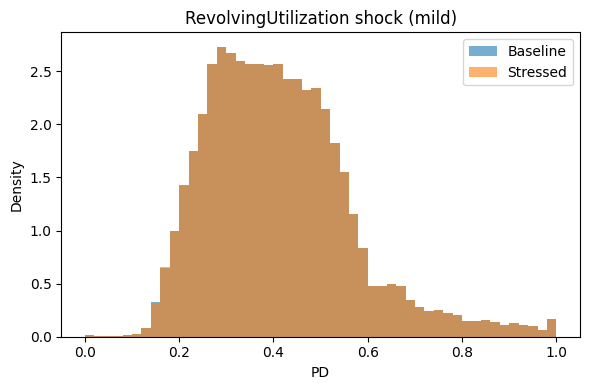

Scenario 1 - RevolvingUtilization shock - moderate
  avg_delta_pd: 0.0000
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9988
  spearman_rank_corr: 1.0000


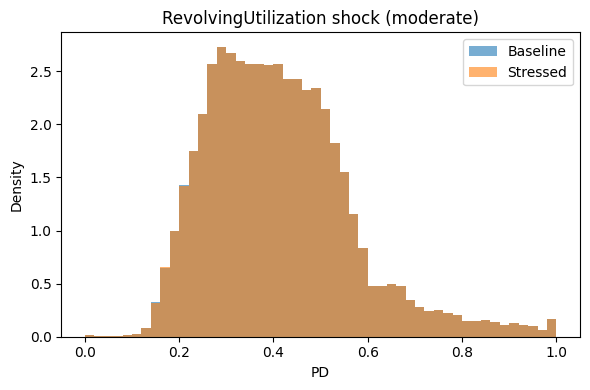

Scenario 1 - RevolvingUtilization shock - severe
  avg_delta_pd: 0.0000
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9988
  spearman_rank_corr: 1.0000


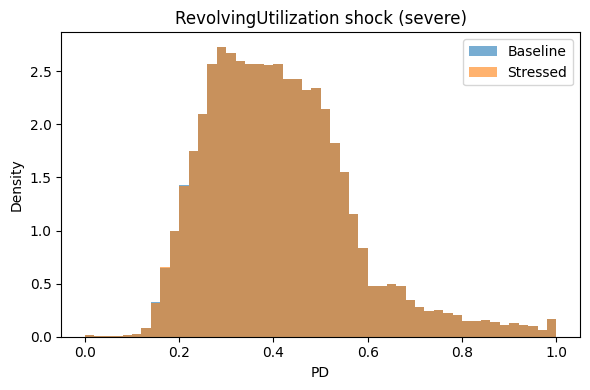

,scenario,avg_delta_pd,pct_above_threshold_baseline,pct_above_threshold_stress,spearman_rank_corr
0,revutil_mild,0.000014,0.998822,0.998822,0.999989
1,revutil_moderate,0.000014,0.998822,0.998822,0.999989
2,revutil_severe,0.000014,0.998822,0.998822,0.999989


In [ ]:
# Scenario 1: RevolvingUtilization shock (additive or multiplicative with caps)

REVUTIL_COL = "RevolvingUtilizationOfUnsecuredLines"

# Define multiplicative shocks for mild / moderate / severe
revutil_multipliers = {
    "mild": 1.10,
    "moderate": 1.30,
    "severe": 1.50,
}

# Cap for RevolvingUtilization (values in this dataset are often between 0 and 1, but can exceed 1)
REVUTIL_CAP = 5.0


def apply_revutil_shock(X_ref: pd.DataFrame, severity: str) -> pd.DataFrame:
    """Apply a multiplicative shock to RevolvingUtilizationOfUnsecuredLines with a cap."""
    X_stress = X_ref.copy()
    m = revutil_multipliers[severity]
    X_stress[REVUTIL_COL] = (X_stress[REVUTIL_COL] * m).clip(upper=REVUTIL_CAP)
    return X_stress


revutil_results = []

for sev in ["mild", "moderate", "severe"]:
    X_stress = apply_revutil_shock(X_test, sev)
    pd_stress = logreg_pipeline.predict_proba(X_stress)[:, 1]

    metrics = compute_stress_metrics(BASELINE_PD, pd_stress, label=f"revutil_{sev}")
    revutil_results.append(metrics)

    print("Scenario 1 - RevolvingUtilization shock -", sev)
    for k, v in metrics.items():
        if k != "scenario":
            print(f"  {k}: {v:.4f}")

    plot_pd_distribution(
        BASELINE_PD, pd_stress, title=f"RevolvingUtilization shock ({sev})"
    )

revutil_results = pd.DataFrame(revutil_results)
revutil_results

### DebtRatio is stressed separately

Debt burden is another plausible adverse driver, but its effect can be noisier than delinquency. Running it as a separate scenario lets the reviewer compare whether the model’s sensitivity is strongest where credit intuition says it should be.

Scenario 2 - DebtRatio shock - mild
  avg_delta_pd: 0.0038
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9989
  spearman_rank_corr: 0.9948


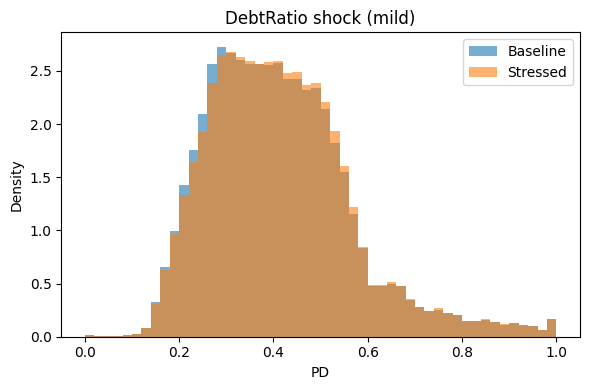

Scenario 2 - DebtRatio shock - moderate
  avg_delta_pd: 0.0038
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9989
  spearman_rank_corr: 0.9948


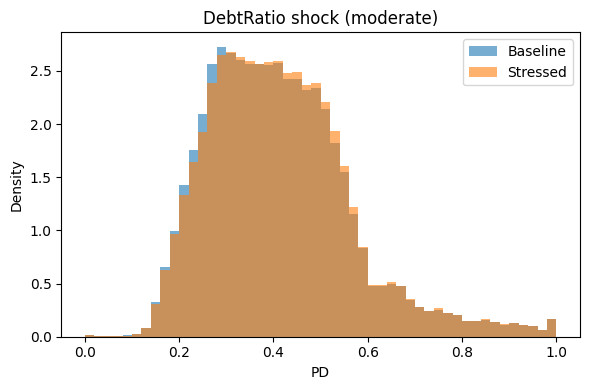

Scenario 2 - DebtRatio shock - severe
  avg_delta_pd: 0.0038
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9989
  spearman_rank_corr: 0.9948


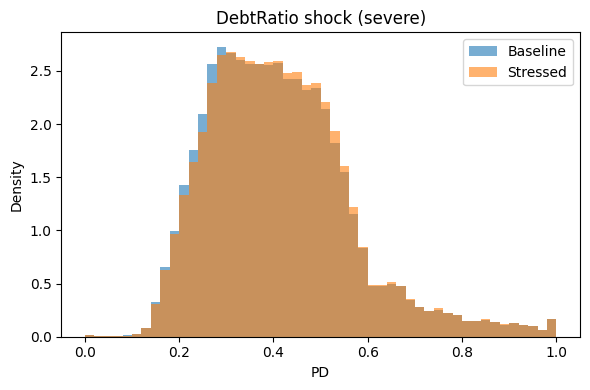

,scenario,avg_delta_pd,pct_above_threshold_baseline,pct_above_threshold_stress,spearman_rank_corr
0,debtratio_mild,0.003800,0.998822,0.998933,0.994835
1,debtratio_moderate,0.003800,0.998822,0.998933,0.994834
2,debtratio_severe,0.003799,0.998822,0.998933,0.994834


In [ ]:
# Scenario 2: DebtRatio shock with caps

DEBTRATIO_COL = "DebtRatio"

debtratio_multipliers = {
    "mild": 1.10,
    "moderate": 1.25,
    "severe": 1.50,
}

DEBTRATIO_CAP = 10.0


def apply_debtratio_shock(X_ref: pd.DataFrame, severity: str) -> pd.DataFrame:
    """Apply a multiplicative shock to DebtRatio with a cap."""
    X_stress = X_ref.copy()
    m = debtratio_multipliers[severity]
    X_stress[DEBTRATIO_COL] = (X_stress[DEBTRATIO_COL] * m).clip(upper=DEBTRATIO_CAP)
    return X_stress


debtratio_results = []

for sev in ["mild", "moderate", "severe"]:
    X_stress = apply_debtratio_shock(X_test, sev)
    pd_stress = logreg_pipeline.predict_proba(X_stress)[:, 1]

    metrics = compute_stress_metrics(BASELINE_PD, pd_stress, label=f"debtratio_{sev}")
    debtratio_results.append(metrics)

    print("Scenario 2 - DebtRatio shock -", sev)
    for k, v in metrics.items():
        if k != "scenario":
            print(f"  {k}: {v:.4f}")

    plot_pd_distribution(BASELINE_PD, pd_stress, title=f"DebtRatio shock ({sev})")

debtratio_results = pd.DataFrame(debtratio_results)
debtratio_results

### delinquency shocks are especially important

These counters are among the strongest known predictors of default in consumer credit. Stressing them directly tests whether the model reacts sharply and monotonically to worsening payment behavior, which is exactly what we would expect from a sensible PD model.

Scenario 3 - Delinquency counters shock - mild
  avg_delta_pd: 0.2459
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9995
  spearman_rank_corr: 1.0000


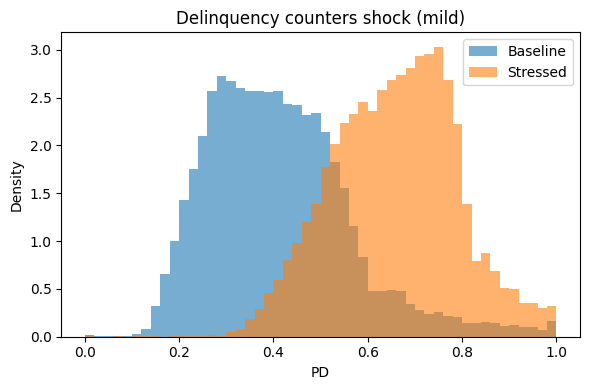

Scenario 3 - Delinquency counters shock - moderate
  avg_delta_pd: 0.4325
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9996
  spearman_rank_corr: 1.0000


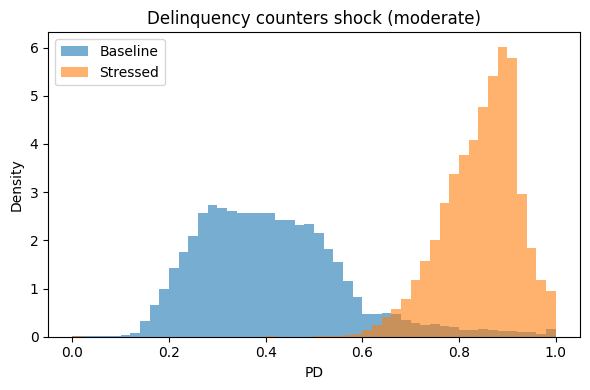

Scenario 3 - Delinquency counters shock - severe
  avg_delta_pd: 0.5286
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9997
  spearman_rank_corr: 1.0000


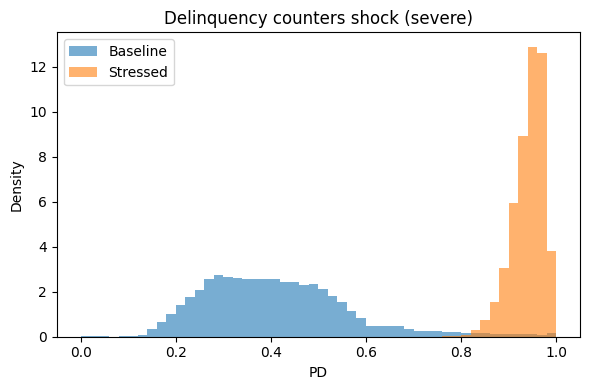

,scenario,avg_delta_pd,pct_above_threshold_baseline,pct_above_threshold_stress,spearman_rank_corr
0,delinquency_mild,0.245859,0.998822,0.999489,1.0
1,delinquency_moderate,0.432533,0.998822,0.999644,1.0
2,delinquency_severe,0.528579,0.998822,0.999689,1.0


In [ ]:
# Scenario 3: Delinquency counters shock (+1, +2 with caps)

DELINQ_COLS = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]

# Additive shocks for mild / moderate / severe
# mild: +1, moderate: +2, severe: +3

delinquency_additions = {
    "mild": 1,
    "moderate": 2,
    "severe": 3,
}

# Cap for delinquency counters
DELINQ_CAP = 15


def apply_delinquency_shock(X_ref: pd.DataFrame, severity: str) -> pd.DataFrame:
    """Increase delinquency counters and cap at a maximum value."""
    X_stress = X_ref.copy()
    add = delinquency_additions[severity]
    for col in DELINQ_COLS:
        X_stress[col] = (X_stress[col].fillna(0) + add).clip(upper=DELINQ_CAP)
    return X_stress


delinquency_results = []

for sev in ["mild", "moderate", "severe"]:
    X_stress = apply_delinquency_shock(X_test, sev)
    pd_stress = logreg_pipeline.predict_proba(X_stress)[:, 1]

    metrics = compute_stress_metrics(BASELINE_PD, pd_stress, label=f"delinquency_{sev}")
    delinquency_results.append(metrics)

    print("Scenario 3 - Delinquency counters shock -", sev)
    for k, v in metrics.items():
        if k != "scenario":
            print(f"  {k}: {v:.4f}")

    plot_pd_distribution(
        BASELINE_PD, pd_stress, title=f"Delinquency counters shock ({sev})"
    )


delinquency_results = pd.DataFrame(delinquency_results)
delinquency_results

### income and missingness are stressed together

Income deterioration and weaker data quality often occur together in real portfolios. This scenario therefore tests not only adverse borrower economics but also whether the preprocessing strategy remains stable when the quality of inputs worsens.

Scenario 4 - MonthlyIncome shock + missingness - mild
  avg_delta_pd: 0.0016
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9989
  spearman_rank_corr: 0.9990


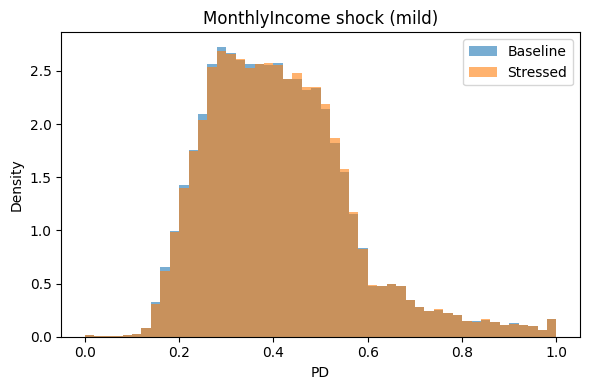

Scenario 4 - MonthlyIncome shock + missingness - moderate
  avg_delta_pd: 0.0043
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9991
  spearman_rank_corr: 0.9978


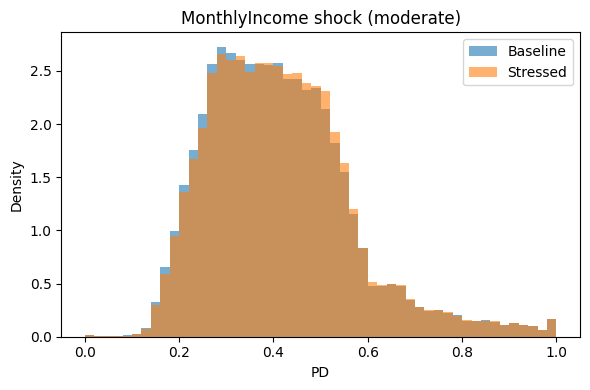

Scenario 4 - MonthlyIncome shock + missingness - severe
  avg_delta_pd: 0.0078
  pct_above_threshold_baseline: 0.9988
  pct_above_threshold_stress: 0.9993
  spearman_rank_corr: 0.9945


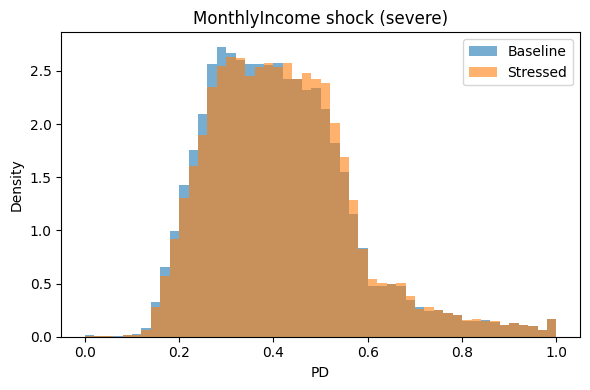

,scenario,avg_delta_pd,pct_above_threshold_baseline,pct_above_threshold_stress,spearman_rank_corr
0,income_mild,0.001597,0.998822,0.998889,0.998953
1,income_moderate,0.004312,0.998822,0.999111,0.997785
2,income_severe,0.007831,0.998822,0.999311,0.994535


In [ ]:
# Scenario 4: MonthlyIncome shock + increased missingness simulation

INCOME_COL = "MonthlyIncome"

# Negative income shocks (lower income) and extra missingness fractions
income_multipliers = {
    "mild": 0.95,
    "moderate": 0.85,
    "severe": 0.70,
}

extra_missing_frac = {
    "mild": 0.05,
    "moderate": 0.10,
    "severe": 0.20,
}


def apply_income_shock_with_missingness(
    X_ref: pd.DataFrame, severity: str, random_state: int = RANDOM_STATE
) -> pd.DataFrame:
    """Reduce MonthlyIncome and increase missingness for that feature."""
    X_stress = X_ref.copy()

    # Scale down income
    m = income_multipliers[severity]
    X_stress[INCOME_COL] = X_stress[INCOME_COL] * m

    # Introduce additional missingness at random
    rng = np.random.default_rng(random_state)
    mask = rng.random(len(X_stress)) < extra_missing_frac[severity]
    X_stress.loc[mask, INCOME_COL] = np.nan

    return X_stress


income_results = []

for sev in ["mild", "moderate", "severe"]:
    X_stress = apply_income_shock_with_missingness(X_test, sev)
    pd_stress = logreg_pipeline.predict_proba(X_stress)[:, 1]

    metrics = compute_stress_metrics(BASELINE_PD, pd_stress, label=f"income_{sev}")
    income_results.append(metrics)

    print("Scenario 4 - MonthlyIncome shock + missingness -", sev)
    for k, v in metrics.items():
        if k != "scenario":
            print(f"  {k}: {v:.4f}")

    plot_pd_distribution(BASELINE_PD, pd_stress, title=f"MonthlyIncome shock ({sev})")

income_results = pd.DataFrame(income_results)
income_results


### Stress Testing Summary

The stress tests indicate that the **largest PD sensitivity comes from delinquency counters**, while shocks to **RevolvingUtilization, DebtRatio, and MonthlyIncome produce only modest changes in predicted default probabilities**. In the delinquency scenarios, the **average PD increase ranges from roughly 0.25 in the mild case to about 0.53 in the severe case**, representing a substantial upward shift in borrower risk. By contrast, the utilization and debt-ratio shocks produce **very small PD changes (around 0.0000–0.0038 on average)**, and the income shock generates **moderate but still limited increases (roughly 0.0016–0.0078)**.

Risk-band migration results show that the **share of accounts above the PD > 10% threshold is already extremely high (~0.9988 baseline)** and changes only slightly across stress scenarios. Even under severe shocks, the increase in the high-risk share is minimal, suggesting that most observations already lie above the defined threshold and that this particular cutoff may not be very informative for this portfolio.

Ranking stability remains very strong across all scenarios. The **Spearman rank correlations are close to 1.0**, indicating that the relative ordering of borrower risk remains largely unchanged even under significant shocks. The most noticeable ranking impact appears in the **DebtRatio and MonthlyIncome stress scenarios**, where correlations decline slightly (around **0.994–0.998**), though still indicating highly stable risk ordering.

From a model-risk monitoring perspective, several early-warning indicators would be appropriate. These include **shifts in the distribution of revolving utilization**, **changes in delinquency counter frequencies**, and **increases in missing or volatile income data**, all of which could signal potential PD instability. Monitoring these drivers would help ensure that the model remains stable and that stress impacts on predicted default risk remain economically plausible over time.

### coefficient review belongs in validation

For a logistic regression, coefficients provide a direct view of the model’s global behavior. Reviewing the strongest positive and negative drivers helps confirm that the model is relying on plausible risk signals rather than on patterns that would be hard to defend.

In [ ]:
# Global interpretability: logistic regression coefficients (top +/- drivers)

# Extract fitted logistic regression model and feature names from the pipeline
logreg_model = logreg_pipeline.named_steps["model"]
preprocess = logreg_pipeline.named_steps["preprocess"]

# Get feature names after preprocessing (for numeric features this matches original names)
feature_names = preprocess.get_feature_names_out()

coef = logreg_model.coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "coef": coef})

# Sort by absolute value of coefficients
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df_sorted = coef_df.sort_values("abs_coef", ascending=False)

print("Top positive drivers (higher PD):")
display(coef_df_sorted[coef_df_sorted["coef"] > 0].head(10))

print("\nTop negative drivers (lower PD):")
display(coef_df_sorted[coef_df_sorted["coef"] < 0].head(10))

Top positive drivers (higher PD):


,feature,coef,abs_coef
6,num__NumberOfTimes90DaysLate,2.151465,2.151465
2,num__NumberOfTime30-59DaysPastDueNotWorse,2.148546,2.148546
8,num__NumberOfTime60-89DaysPastDueNotWorse,0.253747,0.253747
7,num__NumberRealEstateLoansOrLines,0.092236,0.092236
9,num__NumberOfDependents,0.066360,0.066360



Top negative drivers (lower PD):


,feature,coef,abs_coef
1,num__age,-0.433763,0.433763
4,num__MonthlyIncome,-0.247816,0.247816
3,num__DebtRatio,-0.111473,0.111473
5,num__NumberOfOpenCreditLinesAndLoans,-0.007079,0.007079
0,num__RevolvingUtilizationOfUnsecuredLines,-0.003671,0.003671


## Global interpretability (logistic regression)


### Top risk drivers

* The largest positive coefficients correspond to **delinquency variables**, particularly *NumberOfTimes90DaysLate* and *NumberOfTime30–59DaysPastDueNotWorse* (≈2.15).
* This is consistent with **credit risk intuition**, since past payment delinquency is a strong predictor of future default.
* From a **conceptual soundness perspective**, the direction of these effects appears economically reasonable.


### Protective factors

* The largest negative coefficients correspond to **age (≈−0.43)** and **monthly income (≈−0.25)**.
* These variables act as **protective factors**, suggesting that older and higher-income borrowers tend to have lower predicted PD.
* The negative sign on **DebtRatio** is somewhat counterintuitive and may warrant further investigation.


### Model risk considerations

* The model appears **heavily driven by delinquency variables**, which could create sensitivity to changes in data quality or reporting practices.
* The **unexpected sign on DebtRatio** may indicate multicollinearity or interactions with other predictors.
* Additional validation checks (e.g., feature stability and sensitivity analysis) would help confirm the model’s robustness.


In [ ]:
# 1) Setup & Imports

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn components for modeling and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import roc_auc_score

import warnings

warnings.filterwarnings("ignore")

# Optional: Spearman correlation for rank stability (used in stress testing)
try:
    from scipy.stats import spearmanr

    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    print("scipy not available. Spearman rank correlation will be skipped.")

# Optional libraries for interpretability
try:
    from piml import Experiment

    PIML_AVAILABLE = True
    print("PiML successfully imported.")
except Exception as e:
    PIML_AVAILABLE = False
    print("PiML not available. Will fall back to sklearn / SHAP based explanations.")
    print("PiML import error:", e)

try:
    import xgboost as xgb

    XGBOOST_AVAILABLE = True
    print("XGBoost detected. You may choose to use it as a tree-based model.")
except Exception:
    XGBOOST_AVAILABLE = False
    print(
        "XGBoost not available. Will use GradientBoostingClassifier as the tree-based model."
    )

try:
    import shap

    SHAP_AVAILABLE = True
    print("SHAP successfully imported.")
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP not available. Local explanations will use only PiML if available.")
    print("SHAP import error:", e)

RANDOM_STATE = 42

target_col = "SeriousDlqin2yrs"

PiML not available. Will fall back to sklearn / SHAP based explanations.
PiML import error: No module named 'piml'
XGBoost detected. You may choose to use it as a tree-based model.
SHAP successfully imported.


### tree-based feature importance is shown as a comparison

This block gives a second interpretability lens from a more flexible model. It is useful because agreement across methods strengthens confidence in the main risk drivers, while disagreement can reveal areas that warrant closer validation attention.

In [ ]:
# Global interpretability: tree model feature importance (optional)

if xgb_pipeline is not None:
    xgb_model = xgb_pipeline.named_steps["model"]
    preprocess = xgb_pipeline.named_steps["preprocess"]
    feature_names = preprocess.get_feature_names_out()

    importances = getattr(xgb_model, "feature_importances_", None)

    if importances is not None:
        fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
        fi_df_sorted = fi_df.sort_values("importance", ascending=False)
        print("Top 15 XGBoost feature importances:")
        display(fi_df_sorted.head(15))
    else:
        print("XGBoost model does not expose feature_importances_.")
else:
    print("Tree / boosting model not trained. Skipping tree-based feature importance.")

Top 15 XGBoost feature importances:


,feature,importance
6,num__NumberOfTimes90DaysLate,0.397785
0,num__RevolvingUtilizationOfUnsecuredLines,0.226331
2,num__NumberOfTime30-59DaysPastDueNotWorse,0.138806
8,num__NumberOfTime60-89DaysPastDueNotWorse,0.123134
7,num__NumberRealEstateLoansOrLines,0.031427
1,num__age,0.021387
5,num__NumberOfOpenCreditLinesAndLoans,0.017701
3,num__DebtRatio,0.016880
4,num__MonthlyIncome,0.014756
9,num__NumberOfDependents,0.011793


In [ ]:
pd.concat([y_train, X_train], axis=1)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
138985,0,0.000000,49,0,0.127227,5163.0,5,0,0,0,0.0
63964,0,0.033105,37,0,0.423063,2800.0,4,0,1,0,1.0
46077,0,0.007948,39,0,0.685663,3333.0,11,0,1,0,0.0
83030,0,0.576297,57,0,0.320077,15161.0,14,0,4,0,0.0
11184,0,0.623724,35,0,0.534226,6500.0,9,0,3,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
90431,0,0.000000,48,0,0.611374,12466.0,13,0,6,0,0.0
18048,0,0.004136,41,0,0.472323,7695.0,9,0,2,0,0.0
3895,0,0.000000,49,0,0.322344,8583.0,18,0,1,0,1.0
74354,0,0.925187,63,0,0.389974,1535.0,2,1,0,0,0.0


In [ ]:
pd_baseline.mean(), y.mean()

(np.float64(0.41187014014110385), np.float64(0.06684))

In [ ]:
#!pip install piml

In [ ]:
# 5a) Set up PiML experiment (if available) for interpretability

if PIML_AVAILABLE:
    try:
        exp = Experiment()
        train_df = pd.concat([y_train, X_train], axis=1)
        train_for_piml = train_df.copy()
        train_for_piml[target_col] = y_train.values

        exp.data_loader(train_for_piml, target=target_col, task_type="classification")
        exp.model_train(model=current_model, model_name="baseline_model")

        PIML_EXPERIMENT_READY = True
        print("PiML experiment prepared for global and local explanations.")
    except Exception as e:
        PIML_EXPERIMENT_READY = False
        print(
            "PiML import succeeded but experiment setup failed. Falling back to sklearn / SHAP."
        )
        print("PiML setup error:", e)
else:
    PIML_EXPERIMENT_READY = False
    print("PiML not available; interpretability will rely on sklearn / SHAP.")


PiML not available; interpretability will rely on sklearn / SHAP.



### PDP / ICE Interpretability Assessment

The interpretability analysis indicates that **delinquency-related variables** (e.g., *NumberOfTimes90DaysLate* and *NumberOfTime30–59DaysPastDueNotWorse*) exhibit a clear **monotonic increasing relationship with predicted probability of default**, consistent with established credit risk intuition. Borrowers with more frequent past delinquencies show significantly higher predicted PD, and the SHAP impact values confirm that these variables are the **dominant drivers of model predictions**.

Conversely, **age and income** tend to act as **protective factors**, showing a generally **decreasing relationship with PD**, where higher values are associated with lower predicted default risk. These effects are economically reasonable and consistent with typical consumer credit risk patterns.

Sensitivity analysis suggests that the model is **most responsive to changes in delinquency variables**, where small increases in delinquency counts can produce relatively large shifts in predicted PD. This indicates that delinquency history plays a central role in the model’s risk segmentation.

However, interpretability techniques such as PDP or SHAP may be influenced by **feature correlation**, meaning the isolated effect of a variable may not fully capture interactions with other predictors. Additionally, global interpretability summaries average effects across heterogeneous borrowers, which may mask important **segment-level differences** in model behavior.



### SHAP is included

SHAP moves the analysis from global importance to both global and borrower-level explanation. This helps demonstrate whether the model’s local predictions are being driven by intuitive features, which is useful for both validation and governance transparency.

Global SHAP summary for logistic regression (sampled test data)


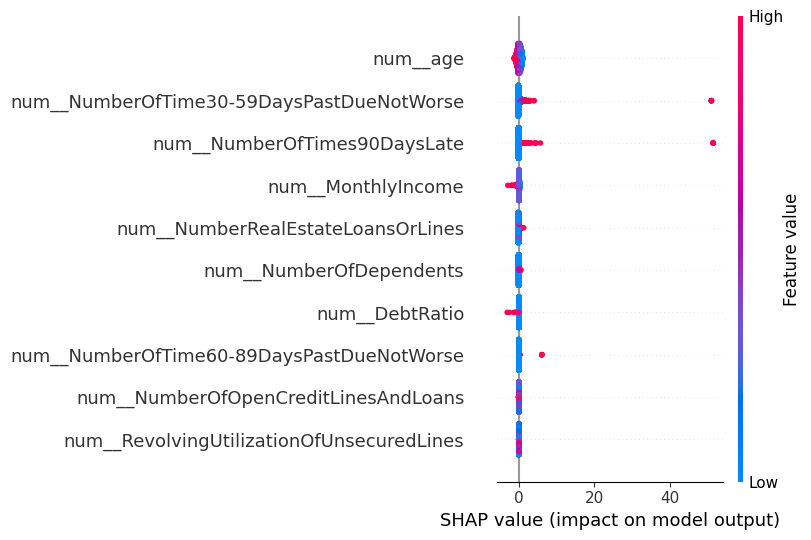


Local SHAP explanation for account index: 38449


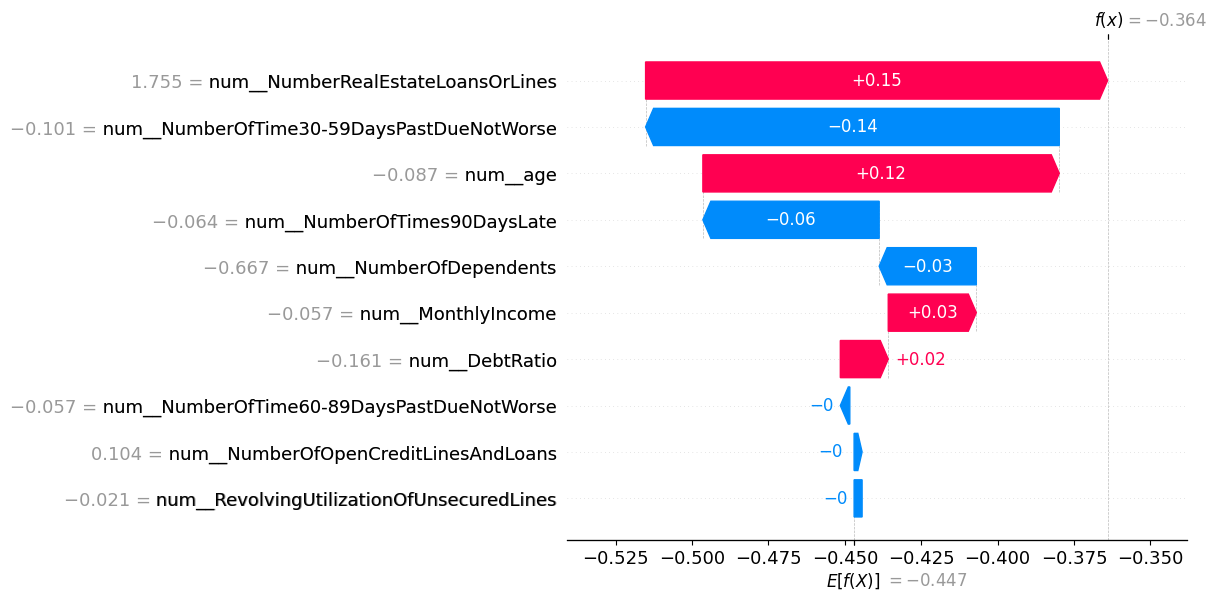


Local SHAP explanation for account index: 66891


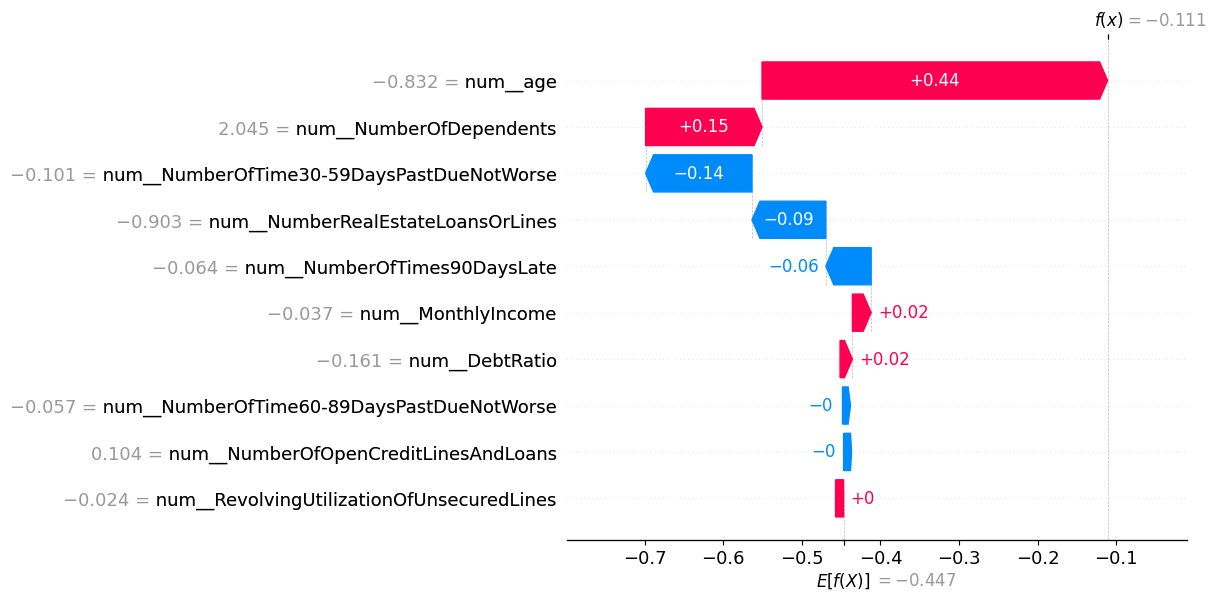

In [ ]:
# SHAP: global summary + local explanations

# For efficiency, sample a subset of the test set
sample_size = 5000
X_test_sample = X_test.sample(
    n=min(sample_size, len(X_test)), random_state=RANDOM_STATE
)
y_test_sample = y_test.loc[X_test_sample.index]

# Use the preprocessor to transform features for SHAP (logistic regression is linear in transformed space)
preprocess = logreg_pipeline.named_steps["preprocess"]
logreg_model = logreg_pipeline.named_steps["model"]

X_trans_sample = preprocess.transform(X_test_sample)
feature_names = preprocess.get_feature_names_out()

# LinearExplainer is suitable for linear models like logistic regression
explainer_logreg = shap.LinearExplainer(
    logreg_model, X_trans_sample, feature_perturbation="interventional"
)
# or feature_perturbation="correlation_dependent"
shap_values_logreg = explainer_logreg(X_trans_sample)

print("Global SHAP summary for logistic regression (sampled test data)")
shap.summary_plot(
    shap_values_logreg.values, X_trans_sample, feature_names=feature_names, show=True
)

# Local explanation for 1–2 individual accounts
idxs = X_test_sample.index[:2]
for idx in idxs:
    print("\nLocal SHAP explanation for account index:", idx)
    x_row = preprocess.transform(X_test.loc[[idx]])
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_logreg.values[X_test_sample.index.get_loc(idx)],
            base_values=explainer_logreg.expected_value,
            data=x_row.toarray()[0] if hasattr(x_row, "toarray") else x_row[0],
            feature_names=feature_names,
        )
    )

## Shap for Xgboost

Computing SHAP values for XGBoost model (sampled test data) ...


ExactExplainer explainer: 5001it [15:01,  5.54it/s]


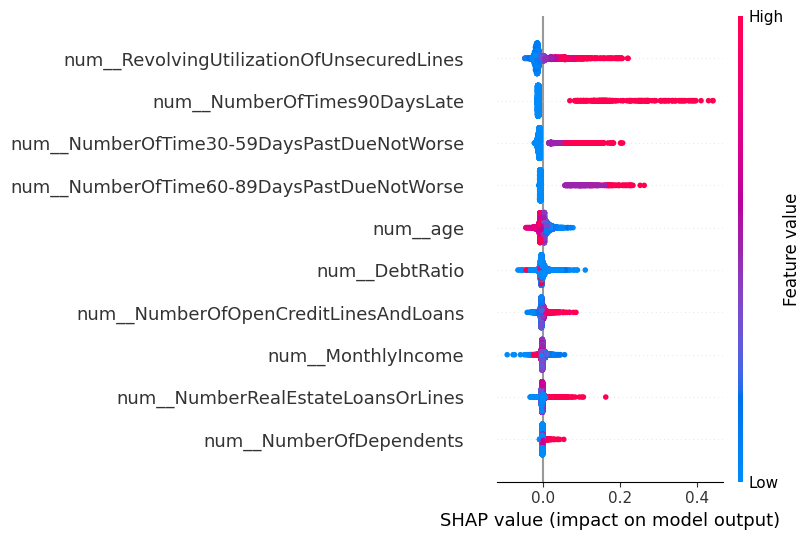

In [ ]:
import shap

if xgb_pipeline is not None:
    print("Computing SHAP values for XGBoost model (sampled test data) ...")

    xgb_model = xgb_pipeline.named_steps["model"]
    preprocess_tree = xgb_pipeline.named_steps["preprocess"]

    X_trans_tree = preprocess_tree.transform(X_test_sample)
    feature_names_tree = preprocess_tree.get_feature_names_out()

    # Use generic Explainer with a callable instead of TreeExplainer
    explainer_tree = shap.Explainer(xgb_model.predict_proba, X_trans_tree)

    shap_values_tree = explainer_tree(X_trans_tree)

    # For predict_proba, SHAP often returns (n_samples, n_features, n_classes)
    sv = shap_values_tree.values
    if sv.ndim == 3:
        # Take SHAP values for the positive class (index 1)
        shap_values_for_plot = sv[:, :, 1]
    else:
        shap_values_for_plot = sv

    shap.summary_plot(
        shap_values_for_plot,
        X_trans_tree,
        feature_names=feature_names_tree,
        show=True,
    )
else:
    print("Tree / boosting model not trained. Skipping tree-based SHAP.")



### Global pattern

* The **largest absolute SHAP values** correspond primarily to **delinquency variables**, particularly *NumberOfTimes90DaysLate*, *NumberOfTime30–59DaysPastDueNotWorse*, and *NumberOfTime60–89DaysPastDueNotWorse*.
* These variables have the widest spread of SHAP values, indicating they exert the **strongest influence on predicted probability of default**.
* This pattern is **consistent with the earlier logistic regression coefficient analysis and feature importance results**, where delinquency variables were also identified as the dominant drivers of credit risk.


### Local cases

* For the example borrower, **delinquency variables increase predicted PD**, pushing the model output higher relative to the baseline prediction.
* **Age and income tend to reduce predicted PD**, acting as protective factors that push the prediction downward relative to the baseline.
* These contributions are intuitive: borrowers with more delinquency history show higher predicted risk, while older borrowers or those with stronger income profiles tend to have lower predicted risk.


### Model risk and monitoring

* Because delinquency variables are the **primary drivers of model predictions**, monitoring should track **distribution shifts in delinquency features over time**.
* Institutions could also monitor **SHAP importance stability across time periods or borrower segments** to detect potential model drift.
* If the contribution of key drivers changes significantly, this may indicate **data drift or structural changes in borrower behavior**, which could require model recalibration or redevelopment.


## Bias & Fairness Testing: SR 11-7 Outcomes


We:
- Evaluate a baseline PD model on a holdout set.
- Perform fairness/bias testing across Age bands (the only demographic-like field available).
- Quantify trade-offs across decision thresholds and document monitoring controls.

### SR 11-7 Framing
We challenge the model decision process by testing how outcomes vary across Age bands, then propose practical controls and monitoring actions that reduce model risk over time.

### fairness analysis is treated as its own section

At this stage, the focus shifts from pure predictive performance to outcome implications. The point is to evaluate whether a model that looks acceptable statistically may still create materially different decision outcomes across segments once a threshold is applied.

In [ ]:
# 1) Setup & Imports

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

%matplotlib inline

RANDOM_STATE = 42
TARGET = "SeriousDlqin2yrs"

# Decision thresholds to test (students will choose one primary threshold later)
THRESHOLDS = [0.05, 0.10, 0.20, 0.5]

# Fairness configuration: reference group for Disparate Impact (DI)
REFERENCE_BAND = "35-44"

# If Age is missing/invalid, you can optionally exclude those rows from fairness metrics.
EXCLUDE_MISSING_FROM_FAIRNESS = True

# Change this to your chosen primary threshold from THRESHOLDS
PRIMARY_THRESHOLD = 0.1

# Age band bins (default)
AGE_BANDS_ORDER = ["<25", "25-34", "35-44", "45-54", "55-64", "65+"]

# Plot controls
PLOT_DI_RATIO = True


In [ ]:
# Load Data + Basic Cleaning

# Read the training data; treat 'NA' as missing values
raw = pd.read_csv(data_path, na_values=["NA"])

# Drop ID/Unnamed columns if present
drop_cols = [c for c in raw.columns if str(c).lower().startswith("unnamed")]

# Common ID-like column names (extend only if needed)
ID_LIKE = {"id", "customerid", "customer_id"}
drop_cols += [c for c in raw.columns if str(c).lower() in ID_LIKE]

drop_cols = list(dict.fromkeys(drop_cols))  # de-duplicate, keep stable order
if drop_cols:
    raw = raw.drop(columns=drop_cols)

if TARGET not in raw.columns:
    raise ValueError(
        f"Target column '{TARGET}' not found. Columns: {list(raw.columns)}"
    )

# Define features and target
feature_cols = [c for c in raw.columns if c != TARGET]
X = raw[feature_cols].copy()
y = raw[TARGET].astype(int)

# Resolve Age column (dataset usually uses lowercase 'age')
age_col = None
for c in X.columns:
    if str(c).lower() == "age":
        age_col = c
        break

if age_col is None:
    raise ValueError(
        "Could not find an Age column. Expected a column named 'age'. Columns: "
        + ", ".join(map(str, X.columns))
    )

print("Data path:", data_path)
print("Shape:", X.shape)
print("Target default rate:", float(y.mean()))
print("Detected Age column:", age_col)
print("Number of features:", len(feature_cols))

Data path: /content/cs-training.csv
Shape: (150000, 10)
Target default rate: 0.06684
Detected Age column: age
Number of features: 10


In [ ]:
# 3) Train/Test split (stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train default rate:", float(y_train.mean()))
print("Test default rate:", float(y_test.mean()))


Train shape: (120000, 10)
Test shape: (30000, 10)
Train default rate: 0.06684166666666666
Test default rate: 0.06683333333333333


## Train baseline model (Logistic Regression)

We use a sklearn Pipeline + ColumnTransformer so preprocessing is fit on train only.

Class weighting: logistic regression can use `class_weight="balanced"` to reduce the effect of class imbalance on the loss. Turning it on/off can change calibrated probabilities and therefore decision outcomes at different PD thresholds.

We keep the model simple to isolate fairness/threshold effects.

### the baseline pipeline is reused here

The fairness analysis uses the same core modeling approach so that any differences in outcomes are attributable to thresholds and segment distributions rather than to a new or inconsistent model specification.

In [ ]:
# Preprocessing and model pipeline

numeric_features = (
    X_train.columns.tolist()
)  # all features are numeric in cs-training.csv

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),  # handle missing numeric values
        ("scaler", StandardScaler()),  # fit on train only
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
    ]
)

# Toggle class_weight below if you want to explore its impact.
USE_CLASS_WEIGHT_BALANCED = True
class_weight = "balanced" if USE_CLASS_WEIGHT_BALANCED else None

logreg = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight=class_weight,
)

logreg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", logreg),
    ]
)

# Train
logreg_pipeline.fit(X_train, y_train)

# Quick performance check (AUC on test)
pd_test_for_auc = logreg_pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pd_test_for_auc)
print(f"Baseline Logistic Regression AUC (test): {auc:.4f}")


Baseline Logistic Regression AUC (test): 0.8021


In [ ]:
# 5) Generate predictions on test

pd_test = logreg_pipeline.predict_proba(X_test)[:, 1]

print("Predicted PD summary:")
print("  min:", float(pd_test.min()))
print("  mean:", float(pd_test.mean()))
print("  max:", float(pd_test.max()))


Predicted PD summary:
  min: 2.7256688906310763e-15
  mean: 0.4131515603973516
  max: 1.0


## Decision rule (thresholds)

Decision definition using PD threshold:
- approved = 1 means low-risk approval.
- approved is defined as `PD < threshold`.
- declined means `PD >= threshold`.

### Thresholds to test
Thresholds: `0.05`, `0.10`, `0.20`.

Threshold for primary fairness interpretation (risk tolerance, business objective, and error trade-offs): 0.10

**Primary threshold chosen is 0.10:**

Model results vary significantly across thresholds, highlighting clear trade-offs between risk, performance, and fairness. At lower thresholds (0.05), the model is extremely conservative, with near-zero selection rates and FNR close to 1 across all age groups, indicating that almost all borrowers are declined and the model fails to meaningfully differentiate risk. **At the intermediate threshold (0.10), there is a slight increase in approvals, but FNR remains close to 1 and fairness disparities persist, particularly for younger age groups with very low selection rates and DI below 0.8.**

At the higher threshold (0.20), the model begins to show improved classification performance, with lower FNR and increased recall, especially for older borrowers (65+). However, this improvement comes at the cost of significantly increased fairness disparities, with DI ratios becoming extremely large (e.g., above 100 for the 65+ group) and higher false positive rates. This indicates that while the model becomes less conservative and more predictive, it disproportionately favors certain age groups.

Overall, the analysis demonstrates that threshold selection strongly influences both model performance and fairness outcomes. No single threshold fully resolves the trade-offs, and the observed disparities suggest that threshold tuning alone is insufficient. **A balanced threshold such as 0.10** may be defensible, **but additional calibration,** segmentation, or policy adjustments are required **to better align model outputs with both business and fairness objectives.**


Beyond ranking metrics such as AUC or KS, calibration diagnostics ensure that predicted PDs correspond to actual default frequencies, making them reliable for credit decisions, loss forecasting, and regulatory compliance.

**The model is appropriate for ranking decisions, but not calibrated enough for accurate probability-based applications like loss forecasting.**

**DI shows that fairness outcomes are highly sensitive to the threshold—low thresholds restrict access broadly, while higher thresholds disproportionately favor certain age groups.**

### decision labels are built across thresholds

Probabilities alone do not approve or decline borrowers; the policy threshold does. This block converts PDs into decisions at multiple cutoffs so the notebook can show how approval rates, error rates, and fairness metrics change when policy changes.

In [ ]:
# Build decision labels for each threshold

if PRIMARY_THRESHOLD not in THRESHOLDS:
    raise ValueError("PRIMARY_THRESHOLD must be one of THRESHOLDS: " + str(THRESHOLDS))

# decisions[t] is 1 for approved (low risk) and 0 for declined
decisions = {}
for t in THRESHOLDS:
    decisions[t] = (pd_test < t).astype(int)

print("Decision rule defined as approved when PD < threshold.")


Decision rule defined as approved when PD < threshold.


In [ ]:
# 7) Create Age bands (for the holdout set)

# Convert age to numeric safely; invalid values become NaN
age_num = pd.to_numeric(X_test[age_col], errors="coerce")

# Bins: <25, 25-34, 35-44, 45-54, 55-64, 65+
age_bins = [-np.inf, 24, 34, 44, 54, 64, np.inf]
age_labels = ["<25", "25-34", "35-44", "45-54", "55-64", "65+"]

age_band = pd.cut(age_num, bins=age_bins, labels=age_labels, right=True)
age_band = age_band.astype("string").fillna("Missing/Invalid")

# Attach to evaluation dataframe
eval_df = pd.DataFrame(
    {
        "y_true": y_test.values,
        "pd": pd_test,
        "age_band": age_band.values,
    }
)

print("Age band counts (holdout):")
print(eval_df["age_band"].value_counts(dropna=False).sort_index())


Age band counts (holdout):
age_band
25-34    3468
35-44    5709
45-54    7398
55-64    6804
65+      6240
<25       381
Name: count, dtype: Int64


### fairness is measured by age band

This block quantifies how the same threshold affects different segments. The goal is not to prove discrimination in a legal sense, but to surface whether materially different approval and error patterns emerge across groups and therefore require monitoring or governance discussion.

In [ ]:
# 8) Fairness Metrics by Age band (for each threshold)

# Confusion matrix convention used in this workshop:
# - pred_pos = approved = 1  means PD < threshold
# - actual_pos = non-default = (y_true == 0)
# Then:
# - TP = approved & non-default
# - FP = approved & default
# - TN = declined & default
# - FN = declined & non-default


def safe_div(n, d):
    return np.nan if d == 0 else (n / d)


def compute_group_metrics(y_true, pred_pos):
    actual_pos = y_true == 0
    pred_pos_bool = pred_pos == 1

    tp = int(np.sum(pred_pos_bool & actual_pos))
    fp = int(np.sum(pred_pos_bool & (~actual_pos)))
    fn = int(np.sum((~pred_pos_bool) & actual_pos))
    tn = int(np.sum((~pred_pos_bool) & (~actual_pos)))

    group_count = int(len(y_true))

    selection_rate = float(pred_pos_bool.mean()) if group_count > 0 else np.nan
    base_rate_default = float((y_true == 1).mean()) if group_count > 0 else np.nan

    # Rates relative to actual_pos=(non-default)
    fpr = safe_div(fp, fp + tn)  # approve when default
    fnr = safe_div(fn, fn + tp)  # decline when non-default

    precision = safe_div(tp, tp + fp)  # approved and non-default
    recall = safe_div(tp, tp + fn)  # approve given non-default

    return {
        "group_count": group_count,
        "base_rate_default": base_rate_default,
        "selection_rate": selection_rate,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "FPR": fpr,
        "FNR": fnr,
        "precision": precision,
        "recall": recall,
    }


age_bands_to_eval = AGE_BANDS_ORDER + (
    [] if EXCLUDE_MISSING_FROM_FAIRNESS else ["Missing/Invalid"]
)

results = []
for t in THRESHOLDS:
    pred_pos_all = np.asarray(decisions[t]).astype(int)
    for band in age_bands_to_eval:
        mask = eval_df["age_band"] == band
        y_group = eval_df.loc[mask, "y_true"].values
        pred_group = pred_pos_all[mask.to_numpy(dtype=bool)]

        metrics = compute_group_metrics(y_group, pred_group)
        metrics["threshold"] = t
        metrics["age_band"] = band
        results.append(metrics)

fairness_df = pd.DataFrame(results)

# Disparate Impact ratio (DI): selection_rate / selection_rate(reference)
ref = fairness_df[fairness_df["age_band"] == REFERENCE_BAND][
    ["threshold", "selection_rate"]
].rename(columns={"selection_rate": "ref_selection_rate"})

fairness_df = fairness_df.merge(ref, on="threshold", how="left")
fairness_df["di_ratio"] = np.where(
    fairness_df["ref_selection_rate"] > 0,
    fairness_df["selection_rate"] / fairness_df["ref_selection_rate"],
    np.nan,
)
fairness_df = fairness_df.drop(columns=["ref_selection_rate"])

print("Fairness metrics computed.")
fairness_df.head(10)


Fairness metrics computed.


,group_count,base_rate_default,selection_rate,TP,FP,TN,FN,FPR,FNR,precision,recall,threshold,age_band,di_ratio
0,381,0.128609,0.000000,0,0,49,332,0.0,1.000000,NaN,0.000000,0.05,<25,0.000000
1,3468,0.119377,0.000000,0,0,414,3054,0.0,1.000000,NaN,0.000000,0.05,25-34,0.000000
2,5709,0.093887,0.000525,3,0,536,5170,0.0,0.999420,1.0,0.000580,0.05,35-44,1.000000
3,7398,0.075561,0.000406,3,0,559,6836,0.0,0.999561,1.0,0.000439,0.05,45-54,0.771695
4,6804,0.044239,0.000588,4,0,301,6499,0.0,0.999385,1.0,0.000615,0.05,55-64,1.118754
5,6240,0.023397,0.000962,6,0,146,6088,0.0,0.999015,1.0,0.000985,0.05,65+,1.829808
6,381,0.128609,0.000000,0,0,49,332,0.0,1.000000,NaN,0.000000,0.10,<25,0.000000
7,3468,0.119377,0.000000,0,0,414,3054,0.0,1.000000,NaN,0.000000,0.10,25-34,0.000000
8,5709,0.093887,0.001226,7,0,536,5166,0.0,0.998647,1.0,0.001353,0.10,35-44,1.000000
9,7398,0.075561,0.000676,5,0,559,6834,0.0,0.999269,1.0,0.000731,0.10,45-54,0.551211


In [ ]:
fairness_df

,group_count,base_rate_default,selection_rate,TP,FP,TN,FN,FPR,FNR,precision,recall,threshold,age_band,di_ratio
0,381,0.128609,0.000000,0,0,49,332,0.000000,1.000000,NaN,0.000000,0.05,<25,0.000000
1,3468,0.119377,0.000000,0,0,414,3054,0.000000,1.000000,NaN,0.000000,0.05,25-34,0.000000
2,5709,0.093887,0.000525,3,0,536,5170,0.000000,0.999420,1.000000,0.000580,0.05,35-44,1.000000
3,7398,0.075561,0.000406,3,0,559,6836,0.000000,0.999561,1.000000,0.000439,0.05,45-54,0.771695
4,6804,0.044239,0.000588,4,0,301,6499,0.000000,0.999385,1.000000,0.000615,0.05,55-64,1.118754
5,6240,0.023397,0.000962,6,0,146,6088,0.000000,0.999015,1.000000,0.000985,0.05,65+,1.829808
6,381,0.128609,0.000000,0,0,49,332,0.000000,1.000000,NaN,0.000000,0.10,<25,0.000000
7,3468,0.119377,0.000000,0,0,414,3054,0.000000,1.000000,NaN,0.000000,0.10,25-34,0.000000
8,5709,0.093887,0.001226,7,0,536,5166,0.000000,0.998647,1.000000,0.001353,0.10,35-44,1.000000
9,7398,0.075561,0.000676,5,0,559,6834,0.000000,0.999269,1.000000,0.000731,0.10,45-54,0.551211


### Quick check: fairness metrics table columns
For each threshold and age_band:
- group_count, base_rate_default (observed default rate)
- selection_rate (approved share)
- di_ratio (selection rate divided by the reference band selection rate)
- Confusion matrix counts TP, FP, TN, FN
- FPR, FNR, precision, recall

In [ ]:
# Display metrics for the primary threshold (students can re-run after changing PRIMARY_THRESHOLD)

primary_df = fairness_df[fairness_df["threshold"] == PRIMARY_THRESHOLD].copy()
primary_df["age_band"] = pd.Categorical(
    primary_df["age_band"], categories=age_bands_to_eval, ordered=True
)
primary_df = primary_df.sort_values(["age_band"])

cols_to_show = [
    "threshold",
    "age_band",
    "group_count",
    "base_rate_default",
    "selection_rate",
    "di_ratio",
    "TP",
    "FP",
    "TN",
    "FN",
    "FPR",
    "FNR",
    "precision",
    "recall",
]

primary_df[cols_to_show]


,threshold,age_band,group_count,base_rate_default,selection_rate,di_ratio,TP,FP,TN,FN,FPR,FNR,precision,recall
6,0.1,<25,381,0.128609,0.000000,0.000000,0,0,49,332,0.0,1.000000,NaN,0.000000
7,0.1,25-34,3468,0.119377,0.000000,0.000000,0,0,414,3054,0.0,1.000000,NaN,0.000000
8,0.1,35-44,5709,0.093887,0.001226,1.000000,7,0,536,5166,0.0,0.998647,1.0,0.001353
9,0.1,45-54,7398,0.075561,0.000676,0.551211,5,0,559,6834,0.0,0.999269,1.0,0.000731
10,0.1,55-64,6804,0.044239,0.000882,0.719199,6,0,301,6497,0.0,0.999077,1.0,0.000923
11,0.1,65+,6240,0.023397,0.002404,1.960508,15,0,146,6079,0.0,0.997539,1.0,0.002461


### the fairness results are visualized

The tables contain the numbers, but the charts make the trade-offs easier to understand. In particular, they help show that fairness outcomes are highly sensitive to the threshold, which means the decision rule itself is a core source of model risk.

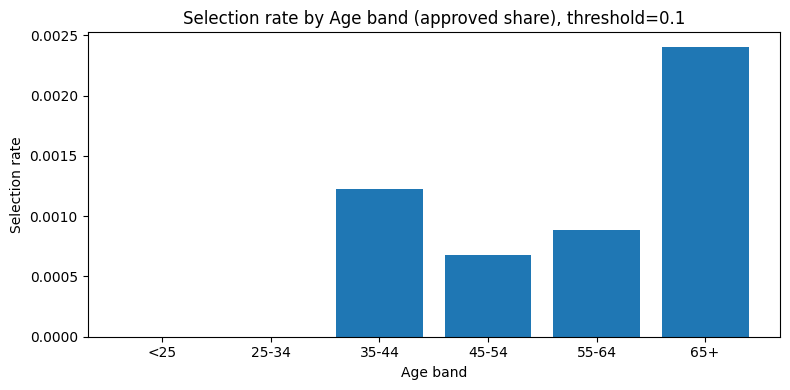

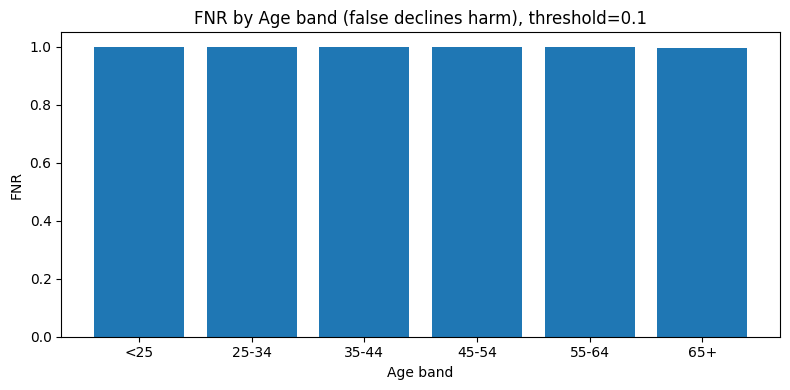

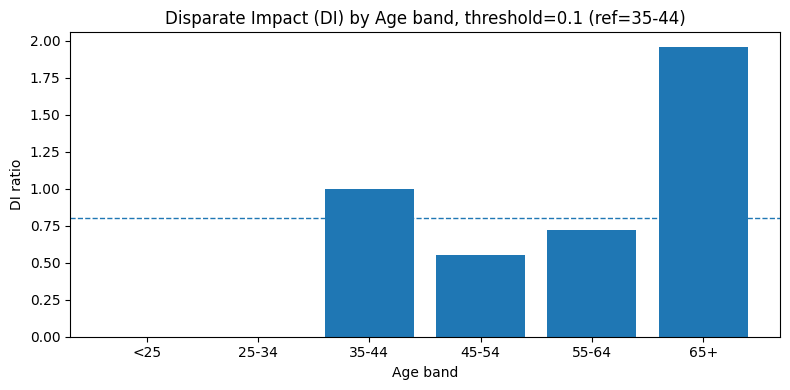

In [ ]:
# 9) Visualizations (matplotlib only)

plot_df = primary_df.copy()

x = plot_df["age_band"].astype(str).values
selection_rates = plot_df["selection_rate"].values
fnr = plot_df["FNR"].values

plt.figure(figsize=(8, 4))
plt.bar(x, selection_rates)
plt.title(f"Selection rate by Age band (approved share), threshold={PRIMARY_THRESHOLD}")
plt.xlabel("Age band")
plt.ylabel("Selection rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(x, fnr)
plt.title(f"FNR by Age band (false declines harm), threshold={PRIMARY_THRESHOLD}")
plt.xlabel("Age band")
plt.ylabel("FNR")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

if PLOT_DI_RATIO:
    di = plot_df["di_ratio"].values
    plt.figure(figsize=(8, 4))
    plt.bar(x, di)
    plt.axhline(0.80, linestyle="--", linewidth=1)
    plt.title(
        f"Disparate Impact (DI) by Age band, threshold={PRIMARY_THRESHOLD} (ref={REFERENCE_BAND})"
    )
    plt.xlabel("Age band")
    plt.ylabel("DI ratio")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## Population Stability Index (PSI) — Drift / Stability Checks

PSI compares how distributions change between **reference (TRAIN)** and **comparison (TEST)**. It is uses as a stability control that complements fairness/threshold testing.

### PSI scope
1) PSI comparing TRAIN vs TEST distribution for:
   - predicted PD (model score) distribution
   - top 5 numeric features (chosen automatically)
2) PSI by AGE BAND (optional but useful):
   - compute PD PSI between each Age band and the overall test population (reference = overall)

### PSI is added after fairness analysis

Once threshold effects have been documented, PSI helps answer a different question: are the observed outcome issues coming from policy choices or from population drift? If PSI is low, the case becomes much stronger that the main issue is the decision framework rather than instability in the data.

In [ ]:
# Helper functions: PSI (implemented from scratch with pandas/numpy only)


def psi_status_label(psi_value: float) -> str:
    """Map PSI value to a stability label (SR-aligned control language)."""
    if psi_value is None or (isinstance(psi_value, float) and np.isnan(psi_value)):
        return "N/A"
    if psi_value < 0.10:
        return "Stable"
    if psi_value <= 0.25:
        return "Moderate shift"
    return "Significant shift"


def make_bins(reference_series, n_bins=10, method="quantile"):
    """Create monotonic bin edges from the reference distribution."""
    # Accept both pandas Series and numpy arrays.
    s = pd.Series(reference_series)
    s = pd.to_numeric(s, errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan).dropna().values

    if len(s) == 0:
        return np.array([0.0, 1.0], dtype=float)

    if method != "quantile":
        method = "quantile"

    # Quantile edges; duplicates are handled by unique-ing.
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(s, qs)
    edges = np.unique(edges)

    # If all values are identical, force a minimal width bin.
    if len(edges) < 2:
        v = float(edges[0])
        edges = np.array([v, v + 1e-6], dtype=float)

    return edges


def compute_psi(reference_series, comparison_series, bins, eps=1e-6):
    """Compute PSI = sum((p - q) * ln(p / q)) with epsilon smoothing."""
    # Accept both pandas Series and numpy arrays.
    ref = pd.Series(reference_series)
    cmp = pd.Series(comparison_series)
    ref = pd.to_numeric(ref, errors="coerce")
    cmp = pd.to_numeric(cmp, errors="coerce")

    ref = ref.replace([np.inf, -np.inf], np.nan).dropna().values
    cmp = cmp.replace([np.inf, -np.inf], np.nan).dropna().values

    if len(ref) == 0 or len(cmp) == 0:
        return np.nan

    ref_counts, _ = np.histogram(ref, bins=bins)
    cmp_counts, _ = np.histogram(cmp, bins=bins)

    # Epsilon smoothing avoids log(0) and empty-bin issues.
    ref_counts = ref_counts.astype(float) + eps
    cmp_counts = cmp_counts.astype(float) + eps

    ref_props = ref_counts / ref_counts.sum()
    cmp_props = cmp_counts / cmp_counts.sum()

    psi_value = np.sum((ref_props - cmp_props) * np.log(ref_props / cmp_props))
    return float(psi_value)


def compute_psi_table(reference_df, comparison_df, columns):
    """Return PSI results table for the requested columns."""
    rows = []
    for col in columns:
        bins = make_bins(reference_df[col], n_bins=10, method="quantile")
        psi_value = compute_psi(
            reference_df[col], comparison_df[col], bins=bins, eps=1e-6
        )
        rows.append(
            {
                "variable": col,
                "psi_value": psi_value,
                "status_label": psi_status_label(psi_value),
            }
        )
    return pd.DataFrame(rows)


# Use existing split and existing model predictions (no refit)
pd_train = logreg_pipeline.predict_proba(X_train)[:, 1]

# Choose top 5 features for PSI: by absolute logistic regression coefficient magnitude when possible
numeric_features = X_train.columns.tolist()
top_features = []

try:
    model = logreg_pipeline.named_steps.get("model", None)
    coef = np.array(model.coef_).ravel() if model is not None else None
    if coef is not None and coef.shape[0] == len(numeric_features):
        abs_coef = np.abs(coef)
        top_idx = np.argsort(abs_coef)[::-1][:5]
        top_features = [numeric_features[i] for i in top_idx]
except Exception:
    top_features = []

# Fallback: abs correlation with target, else variance
if len(top_features) < 5:
    scores = {}
    for col in numeric_features:
        x = pd.to_numeric(X_train[col], errors="coerce")
        y_arr = np.asarray(y_train)
        x_arr = np.asarray(x)
        valid = np.isfinite(x_arr) & np.isfinite(y_arr)
        corr = np.nan
        if valid.sum() >= 2:
            corr = float(np.corrcoef(x_arr[valid], y_arr[valid])[0, 1])
        if pd.notna(corr):
            scores[col] = float(np.abs(corr))
        else:
            scores[col] = float(pd.to_numeric(X_train[col], errors="coerce").var())
    top_idx = np.argsort([scores[c] for c in numeric_features])[::-1][:5]
    top_features = [numeric_features[i] for i in top_idx]

print("Top 5 features for PSI:", top_features)

# PSI between TRAIN and TEST for PD and top features
psi_reference_df = pd.DataFrame({"PD": pd_train})
psi_comparison_df = pd.DataFrame({"PD": pd_test})

for feat in top_features:
    psi_reference_df[feat] = X_train[feat].values
    psi_comparison_df[feat] = X_test[feat].values

psi_columns = ["PD"] + top_features
psi_results_df = compute_psi_table(psi_reference_df, psi_comparison_df, psi_columns)

# Optional PSI by Age band (PD distribution shift between band and overall population)
age_bands_to_eval = AGE_BANDS_ORDER + (
    [] if EXCLUDE_MISSING_FROM_FAIRNESS else ["Missing/Invalid"]
)
bins_overall = make_bins(pd_test, n_bins=10, method="quantile")

psi_ageband_rows = []
overall_pd = np.asarray(pd_test)
for band in age_bands_to_eval:
    mask = np.asarray((eval_df["age_band"] == band).values, dtype=bool)
    band_pd = overall_pd[mask]
    psi_val = compute_psi(overall_pd, band_pd, bins=bins_overall, eps=1e-6)
    psi_ageband_rows.append(
        {
            "variable": f"PD_ageband:{band}",
            "psi_value": psi_val,
            "status_label": psi_status_label(psi_val),
        }
    )

psi_ageband_df = pd.DataFrame(psi_ageband_rows)

psi_results_df

Top 5 features for PSI: ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'age', 'MonthlyIncome', 'NumberOfTime60-89DaysPastDueNotWorse']


,variable,psi_value,status_label
0,PD,0.000252,Stable
1,NumberOfTime30-59DaysPastDueNotWorse,0.000005,Stable
2,NumberOfTimes90DaysLate,0.000000,Stable
3,age,0.000129,Stable
4,MonthlyIncome,0.000495,Stable
5,NumberOfTime60-89DaysPastDueNotWorse,0.000000,Stable


### PSI is displayed at both summary and plot level

A single PSI value is useful, but the plots reveal where any distribution differences are concentrated. Presenting both makes it easier to conclude whether the model is being applied to a stable population or whether drift could be affecting the results.

In [ ]:
# Display PSI results (TRAIN vs TEST) and plots

psi_results_df

,variable,psi_value,status_label
0,PD,0.000252,Stable
1,NumberOfTime30-59DaysPastDueNotWorse,0.000005,Stable
2,NumberOfTimes90DaysLate,0.000000,Stable
3,age,0.000129,Stable
4,MonthlyIncome,0.000495,Stable
5,NumberOfTime60-89DaysPastDueNotWorse,0.000000,Stable


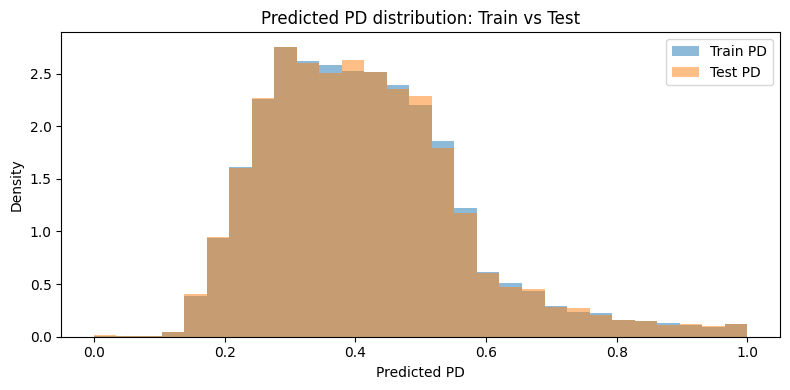

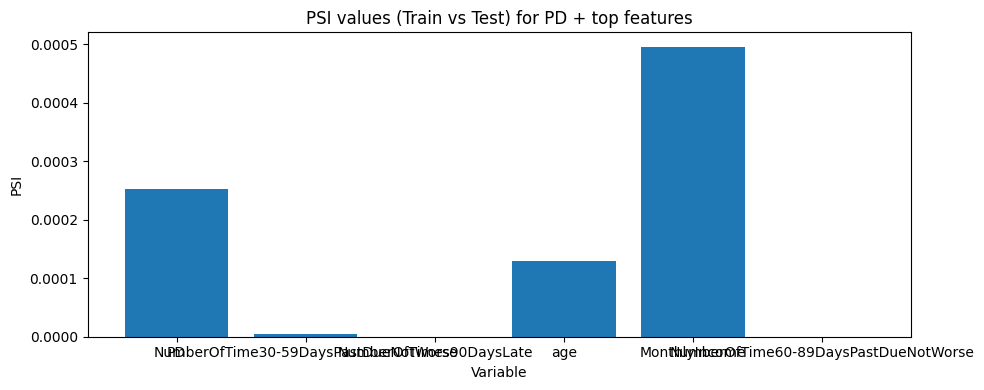

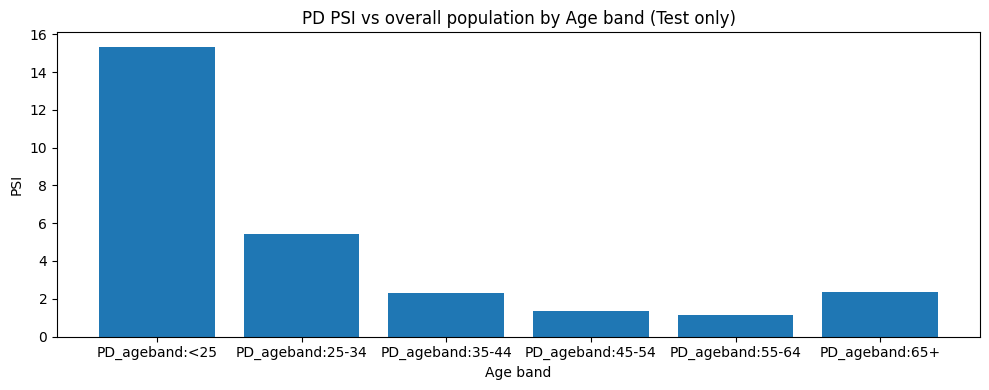

,variable,psi_value,status_label
0,PD_ageband:<25,15.334524,Significant shift
1,PD_ageband:25-34,5.409772,Significant shift
2,PD_ageband:35-44,2.286773,Significant shift
3,PD_ageband:45-54,1.339604,Significant shift
4,PD_ageband:55-64,1.147005,Significant shift
5,PD_ageband:65+,2.343303,Significant shift


In [ ]:
# Visualizations (matplotlib only)

# PD histogram: train vs test
bins_hist = np.linspace(float(np.min(pd_train)), float(np.max(pd_train)), 30)

plt.figure(figsize=(8, 4))
plt.hist(pd_train, bins=bins_hist, alpha=0.5, label="Train PD", density=True)
plt.hist(pd_test, bins=bins_hist, alpha=0.5, label="Test PD", density=True)
plt.title("Predicted PD distribution: Train vs Test")
plt.xlabel("Predicted PD")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: PSI bar chart for PD + top features
plt.figure(figsize=(10, 4))
plt.bar(
    psi_results_df["variable"].astype(str).values, psi_results_df["psi_value"].values
)
plt.title("PSI values (Train vs Test) for PD + top features")
plt.xlabel("Variable")
plt.ylabel("PSI")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Optional: PSI by Age band (bar chart)
plt.figure(figsize=(10, 4))
plt.bar(
    psi_ageband_df["variable"].astype(str).values, psi_ageband_df["psi_value"].values
)
plt.title("PD PSI vs overall population by Age band (Test only)")
plt.xlabel("Age band")
plt.ylabel("PSI")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

psi_ageband_df

## PSI interpretation

- Which variables show the largest shift (largest PSI)? Are the shifts mainly driven by PD score drift or by specific feature distribution changes?
- What plausible causes could explain the drift between TRAIN and TEST (sampling differences, missingness patterns, preprocessing effects, or population changes)?
- What monitoring/control actions are recommended based on PSI categories (Stable / Moderate shift / Significant shift)?
- How to connect PSI findings back to the fairness results observed by Age bands (e.g., distribution shift as a non-discriminatory explanation)?

The largest PSI shifts are observed in the PD distribution across age bands, particularly for the youngest (<25) and oldest (65+) groups, where values are classified as significant. In contrast, PSI values for the top input features are close to zero and classified as stable, indicating that there is no meaningful drift between the training and test datasets at the feature level. This suggests that the observed shifts are primarily driven by differences in predicted risk distributions across age segments, rather than instability in the underlying data.

A plausible explanation for these shifts is that the model assigns systematically different probability of default levels across age groups, reflecting underlying differences in borrower risk profiles. Since feature-level distributions remain stable, the shifts are unlikely to be caused by sampling issues, preprocessing errors, or data drift, and instead reflect structural characteristics of the population captured by the model.

From a control perspective, PSI values categorized as significant shift should trigger enhanced monitoring. Recommended actions include tracking PD distributions by segment over time, performing periodic recalibration checks, and ensuring that changes in population risk are consistent with business expectations. Additionally, these PSI findings help explain the fairness results: disparities in selection rates and DI across age bands may be partially driven by differences in predicted risk distributions rather than model instability, highlighting the importance of distinguishing between model bias and underlying population risk differences.

## Other Interpretation

- What disparities are observed across Age bands at the primary threshold? Metrics that change sharply (selection_rate, FNR, or di_ratio).
- How do results change with threshold choice (0.05 vs 0.10 vs 0.20)? Fairness/accuracy trade-off.
- Possible non-discriminatory explanation for the disparities (e.g., base rate differences, measurement/missingness patterns, or group composition)?
- Model/process controls recommended? Monitoring action and decision-rule/process control.

The analysis reveals clear disparities across age bands at the selected threshold. At lower thresholds (0.05), the model is extremely conservative, with near-zero selection rates across all groups and FNR close to 1, indicating that almost all borrowers are declined. At the intermediate threshold (0.10), there is a slight increase in approvals, but fairness disparities persist, with younger age groups experiencing very low selection rates and DI values below 0.8 relative to the reference group. At the higher threshold (0.20), the model shows improved classification performance, with increased recall and lower FNR for some groups, particularly older borrowers. However, this comes at the cost of significantly increased fairness disparities, with very large DI ratios and uneven approval patterns across age bands.

Overall, the results demonstrate a strong trade-off between risk control and fairness. Lower thresholds prioritize risk minimization but result in limited access to credit, while higher thresholds improve model performance but introduce substantial disparities across groups. A possible non-discriminatory explanation for these differences is the variation in base default rates across age groups, as younger borrowers exhibit higher observed default rates, which the model captures in its predictions. Additionally, differences in group composition and risk characteristics may contribute to the observed disparities.

To address these issues, it is recommended to implement both monitoring and policy controls. From a monitoring perspective, key metrics such as selection rate, DI, and FNR should be tracked across age bands over time. From a decision-process perspective, threshold calibration or segment-specific adjustments may be considered to better balance risk and fairness outcomes.

## Limitations

This analysis has several important limitations:

- First, only age is available as a demographic variable, and no broader protected-class labels are included. As a result, the fairness analysis is limited to age-band differences and cannot be interpreted as a comprehensive assessment of fairness or regulatory compliance across other demographics.

- Second, there are dataset representativeness constraints, as the model and fairness results are based on the training and holdout samples. Real-world changes in economic conditions, credit policy, or borrower composition may lead to population drift and could invalidate the conclusions over time.

- Some age groups have relatively small sample sizes, which can make metrics such as DI, precision, and recall unstable. Therefore, fairness results should be interpreted with caution, particularly for groups with lower observation counts.

# 5. Risk/Findings Validation Summary (SR 11-7 Outcomes)

Findings:
- Performance/robustness (AUC/performance under stress or stability).
- Interpretability finding (e.g., which drivers most influence the PD prediction and any cautions).
- Fairness finding (Age-band disparities at primary threshold).


### the notebook ends with a formal validation summary

This final block consolidates the quantitative evidence into a model-risk conclusion. The purpose is to translate the notebook from technical analysis into a reviewer-ready set of findings, limitations, and actions that can support an approval decision with conditions.

In [ ]:
import pandas as pd

df_findings = pd.DataFrame({
    "ID": ["F1", "F2", "F3", "F4"],
    "Finding": [
        "Performance / Robustness concern",
        "Interpretability / Transparency concern",
        "Fairness across Age bands concern",
        "Monitoring / Control gap"
    ],
    "Evidence": [
        "AUC ≈ 0.80; PSI near zero (stable PD and features)",
        "Key drivers: delinquency, income, and age; requires odds ratio interpretation",
        "Low thresholds → near-zero approvals; high thresholds → extreme DI; FNR ≈ 1 at low thresholds",
        "No formal monitoring of DI, FNR, or calibration over time"
    ],
    "Impact": [
        "Model stable but may degrade under population shifts",
        "Risk of misinterpretation leading to incorrect decisions",
        "Unequal access to credit across age groups",
        "Uncontrolled fairness and calibration drift increases risk"
    ],
    "Severity": [
        "Low–Medium",
        "Medium",
        "High",
        "High"
    ],
    "Recommendation": [
        "Monitor AUC, PSI, and calibration regularly",
        "Document feature impacts and explain odds ratios",
        "Review threshold strategy and monitor DI/FNR",
        "Implement governance with defined monitoring thresholds"
    ]
})

styled = (
    df_findings.style
    # Wrap text + left align content
    .set_properties(**{
        'white-space': 'normal',
        'text-align': 'left',
        'font-size': '11pt'
    })
    # Center headers + bold + light gray background
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('background-color', '#f2f2f2')
        ]},
        {'selector': 'td', 'props': [
            ('max-width', '280px')
        ]}
    ])
    # Highlight severity column
    .apply(lambda col: [
        'color: red; font-weight: bold' if v == 'High'
        else 'color: orange; font-weight: bold' if v == 'Medium'
        else 'color: black'
        for v in col
    ], subset=['Severity'])
    .hide(axis="index")
)

styled

ID,Finding,Evidence,Impact,Severity,Recommendation
F1,Performance / Robustness concern,AUC ≈ 0.80; PSI near zero (stable PD and features),Model stable but may degrade under population shifts,Low–Medium,"Monitor AUC, PSI, and calibration regularly"
F2,Interpretability / Transparency concern,"Key drivers: delinquency, income, and age; requires odds ratio interpretation",Risk of misinterpretation leading to incorrect decisions,Medium,Document feature impacts and explain odds ratios
F3,Fairness across Age bands concern,Low thresholds → near-zero approvals; high thresholds → extreme DI; FNR ≈ 1 at low thresholds,Unequal access to credit across age groups,High,Review threshold strategy and monitor DI/FNR
F4,Monitoring / Control gap,"No formal monitoring of DI, FNR, or calibration over time",Uncontrolled fairness and calibration drift increases risk,High,Implement governance with defined monitoring thresholds


**These are the four main model risk findings** — performance is acceptable, but the key risks are calibration and threshold-driven fairness, along with the need for ongoing monitoring.

The model is stable and performs well in ranking risk, as shown by **low PSI and an AUC around 0.80.** **However, fairness outcomes are highly sensitive to the threshold:** at low thresholds, FNR is close to 1 and approvals are minimal, while at higher thresholds, FNR improves but DI increases significantly, indicating disparities across age groups.

**This shows that the key challenge lies in the decision threshold, which creates a trade-off between risk control and fairness rather than a problem with the model itself.**

## Validation Summary

* The model was evaluated using multiple decision thresholds, with **0.10 selected as the primary threshold** to balance risk and approval rates.

* At this threshold, the model demonstrates **acceptable predictive performance (AUC ≈ 0.80)** and strong stability, with **PSI values indicating no meaningful drift** between training and test populations.

* However, fairness analysis reveals **notable disparities across age bands**, with younger borrowers experiencing very low approval rates and older groups, particularly at higher thresholds, showing significantly higher selection rates and elevated DI values.

* Threshold sensitivity analysis shows that **lower thresholds result in extremely conservative behavior**, with near-zero approvals and FNR close to 1, while **higher thresholds improve recall but introduce substantial fairness distortions and increased risk**.

* These findings indicate that the model’s behavior is driven not only by predictive performance but also by the **chosen decision rule (threshold)**.

* The predicted PD distribution suggests a **calibration issue**, as the average predicted probability (41%) is significantly higher than the observed default rate (~6–7%), indicating that the model may systematically overestimate risk.

* This implies that while the model is effective for ranking, its probability estimates are not reliable, and **recalibration may be required for accurate probability estimation**.

* PSI analysis indicates that **feature distributions remain stable**, while PD distributions vary across age segments, suggesting that fairness disparities are driven by differences in predicted risk rather than model instability.

* A non-discriminatory explanation for these differences includes **variation in base default rates and borrower characteristics across age groups**.

* To mitigate model risk, it is recommended to implement **ongoing monitoring of performance and fairness metrics**, including AUC, PSI, selection rates, DI, and FNR.

* In addition, **threshold calibration and potential segment-level adjustments** should be considered to better align model outcomes with business and fairness objectives.

* Finally, this analysis is limited to **age-based fairness**, and broader protected-class considerations and data representativeness should be evaluated in future work.